# Business Analytics Case Study — Bengaluru Restaurants

**Name:** Poojitha D.
**Course:** Business Analytics
**Dataset:** `restaurant_cleaned.csv` (already preprocessed in the earlier notebook)

This notebook continues from the cleaned dataset and covers the actual
analysis part of the case study — EDA, relationships between variables,
feature importance, model building, and business insights.

This one uses the dataset `restaurant_cleaned.csv`.


## Section 1: Data Loading & Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_curve, roc_auc_score)

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')
sns.set_palette('deep')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

df = pd.read_csv('Downloads/restaurant_cleaned.csv')
print(df.shape)
df.head()


(6335, 35)


,title,categoryName,description,price,totalScore,reviewsCount,imagesCount,address,neighborhood,street,city,postalCode,state,website,phone,location.lat,location.lng,openingHours,reviewsDistribution.oneStar,reviewsDistribution.twoStar,reviewsDistribution.threeStar,reviewsDistribution.fourStar,reviewsDistribution.fiveStar,Features,price_numeric,High Rated,Reservations,Parking,Delivery,Outdoor Seating,Takeout,Vegetarian Options,Wheelchair Accessible,Family Friendly,Pet Friendly
0,080 International Lounge - Bangalore Airport,International,NaN,NaN,3.5,3.0,NaN,Kempegowda International Airport Bengaluru Lev...,Kempegowda International Airport Bengaluru Lev...,Kempegowda International Airport Bengaluru Lev...,Bengaluru,560300,Karnataka,NaN,+91 86575 41678,13.070601,77.791855,NaN,NaN,NaN,NaN,NaN,NaN,,300.0,0.0,0,0,0,0,0,0,0,0,0
1,1 Bar House Kitchen (1BHK),Restaurant,NaN,"₹600–1,800",4.3,3401.0,3196.0,"56, Raj villa, 5th cross, 60 Feet Rd, 6th Bloc...","KHB Colony, 6th Block, Koramangala","56, Raj villa, 5th cross, 60 Feet Rd",Bengaluru,560095.0,Karnataka,NaN,+91 95914 26566,12.936549,77.621132,"[{'day': 'Monday', 'hours': '12 to 11:45\u202f...",142.0,102.0,251.0,905.0,2001.0,Accepts reservations | Alcohol | All you can e...,1200.0,1.0,1,1,1,1,1,1,1,1,0
2,"1 By 2, Veg Restaurant",,NaN,NaN,3.0,1.0,NaN,"67 8'th Main Road Vasanthnagar, Bengaluru 5600...",67 8'th Main Road Vasanthnagar,67 8'th Main Road Vasanthnagar,Bengaluru,560052,Karnataka,NaN,+91 97407 12746,13.058670,77.565420,NaN,NaN,NaN,NaN,NaN,NaN,,300.0,0.0,0,0,0,0,0,0,0,0,0
3,100 ft,Italian Mediterranean,NaN,NaN,4.0,112.0,NaN,"777/I 100 Ft Road, Bengaluru 560038 India",777/I 100 Ft Road,777/I 100 Ft Road,Bengaluru,560038,Karnataka,NaN,+91 98864 88439,12.879450,77.559670,NaN,NaN,NaN,NaN,NaN,NaN,Reservations Seating Parking Available Serves ...,300.0,1.0,1,1,0,1,0,0,0,0,0
4,1131 Bar + Kitchen,Italian Indian Bar Mediterranean Asian Grill,1131 was created as an easy going place to hav...,₹600–800,4.0,30.0,NaN,"1131, 100 Feet Rd Indira Nagar 2nd Stage, Beng...",100 Feet Rd Indira Nagar 2nd Stage,1131,Bengaluru,560038,Karnataka,https://www.zomato.com/bangalore/1131-bar-kitc...,+91 80 2520 1112,12.969852,77.641426,NaN,0.0,4.0,41.0,127.0,81.0,Reservations Seating Serves Alcohol Table Serv...,700.0,1.0,1,0,0,1,0,0,0,0,0


## Section 2: Data Preprocessing


In [2]:
raw_rows, raw_cols = 10164, 24
final_rows, final_cols = df.shape

print("Original rows :", raw_rows)
print("Final rows    :", final_rows)
print("Rows removed  :", raw_rows - final_rows)
print()
print("Original columns:", raw_cols)
print("Final columns    :", final_cols)


Original rows : 10164
Final rows    : 6335
Rows removed  : 3829

Original columns: 24
Final columns    : 35


Row number decreased from 10,164 to 6,335. Most of them are restaurants that have zero reviews (or missing
reviews counts). The lack of reviews means the lack of rating data, so there is no need to keep such records. The check for duplicated rows was done using the preprocessing notebook and there were 0 duplicate rows. This means that in this particular dataset it wasn't the duplicates that caused the decrease in rows but rather the zero-review filter.

Column number has been increased from 24 to 35. It happened because the original 'Features' column was a single field with a set of services that are available at each restaurant listed there in one big string (parking, delivery, reservations, etc). It is not very useful and therefore it was transformed into separate 0/1 columns for each service. Also, there is 'price_numeric' (cleaned price range) and 'High Rated' (rating 0/1) added to it.

This allows to use features more flexibly. For example, you can check whether restaurants with parking receive
higher ratings or not.


### The features that got extracted from `Features`

- **Reservations** — restaurants that accept reservations usually put more
  effort into the dine-in experience. It is useful in checking if that shows up in the
  ratings.
- **Parking** — parking is a convenience factor. Need to check whether it actually
  correlates with better ratings or if it's unrelated.
- **Delivery** — a lot of places offer delivery now, so this is more about
  whether it's a differentiator or just standard.
- **Outdoor Seating** — outdoor seating usually means a different kind of
  dining experience (cafes, casual places). Might show a pattern with ratings.
- **Takeout** — similar to delivery, this is about convenience rather than
  the core dining experience.
- **Vegetarian Options** — Bengaluru has a large vegetarian-eating population,
  so this could actually matter more here than it would elsewhere.
- **Wheelchair Accessible** — accessibility isn't something every place
  invests in, so restaurants that do might also be more customer-focused
  overall.
- **Family Friendly** — worth checking if family-oriented restaurants score
  differently from others.
- **Pet Friendly** — a smaller feature


In [3]:
# quick check of how common each engineered feature actually is
feature_cols_list = ['Reservations', 'Parking', 'Delivery', 'Outdoor Seating',
                      'Takeout', 'Vegetarian Options', 'Wheelchair Accessible',
                      'Family Friendly', 'Pet Friendly']

for col in feature_cols_list:
    pct = df[col].mean() * 100
    print(f"{col:<22}: {pct:.1f}% of restaurants have this")


Reservations          : 23.2% of restaurants have this
Parking               : 19.9% of restaurants have this
Delivery              : 18.0% of restaurants have this
Outdoor Seating       : 26.8% of restaurants have this
Takeout               : 24.2% of restaurants have this
Vegetarian Options    : 6.9% of restaurants have this
Wheelchair Accessible : 8.2% of restaurants have this
Family Friendly       : 12.7% of restaurants have this
Pet Friendly          : 1.0% of restaurants have this


Parking and Reservations are the most common of the extracted features,
while Pet Friendly is quite rare — most restaurants in the
dataset are not built around pets. if
a feature is present in only 3-4% of the data, any pattern involving it
should be read a bit cautiously since the sample is small.


## Section 3: Exploratory Data Analysis



In [4]:
# small helper used later for a couple of the categorical columns
def clean_category(val):
    """categoryName has a lot of entries that are just blank spaces
    instead of NaN, so this cleans that up into a proper 'Unknown' label."""
    if pd.isna(val):
        return 'Unknown'
    val = str(val).strip()
    return val if val != '' else 'Unknown'

df['cuisine'] = df['categoryName'].apply(clean_category)

# a simple price bucket, useful for a couple of the bar charts later
def price_bucket(p):
    if p <= 200:
        return 'Budget (<=200)'
    elif p <= 400:
        return 'Mid-range (201-400)'
    elif p <= 800:
        return 'Premium (401-800)'
    else:
        return 'Fine Dining (800+)'

df['price_category'] = df['price_numeric'].apply(price_bucket)

print(df['cuisine'].nunique(), "unique cuisine labels")
print(df['price_category'].value_counts())


839 unique cuisine labels
price_category
Mid-range (201-400)    3177
Budget (<=200)         2128
Premium (401-800)       804
Fine Dining (800+)      226
Name: count, dtype: int64


### Rating Distribution


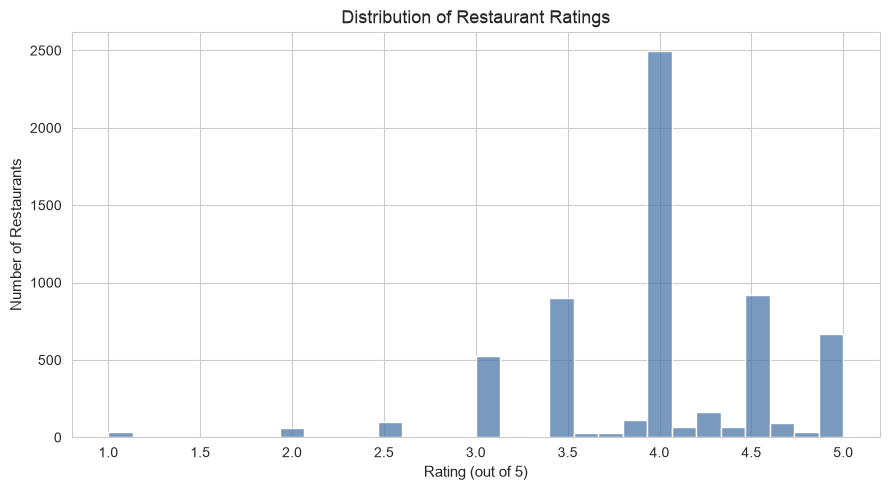

In [5]:
plt.figure(figsize=(9, 5))
sns.histplot(df['totalScore'], bins=30, color='#4C78A8', kde=False)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()


In [6]:
print(df['totalScore'].describe())


count    6335.000000
mean        3.977316
std         0.641961
min         1.000000
25%         3.500000
50%         4.000000
75%         4.500000
max         5.000000
Name: totalScore, dtype: float64


**Observation:** Most ratings are bunched up between 3.5 and 4.5, and the
median is exactly 4.0. There isn't much on the low end (below 2.5) — very few
restaurants get rated that badly. The distribution is skewed left, so bad
ratings are the exception rather than the norm.

**Business Insight:** Since most restaurants already sit in the 3.5-4.5
range, a rating of 4.0 doesn't automatically mean a restaurant stands out —
it's basically average for this dataset. Anything above 4.5 is where a
restaurant is actually distinguishing itself from others.


### Price Distribution


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/654707566.py:6: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Cellar/jupyterlab/4.5.9/libexec/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


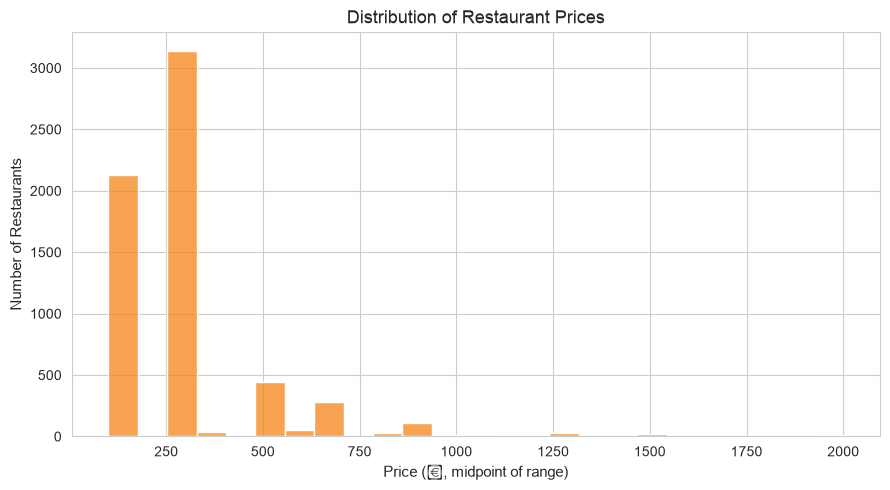

In [7]:
plt.figure(figsize=(9, 5))
sns.histplot(df['price_numeric'], bins=25, color='#F58518', kde=False)
plt.title('Distribution of Restaurant Prices')
plt.xlabel('Price (₹, midpoint of range)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3451353450.py:5: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Cellar/jupyterlab/4.5.9/libexec/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


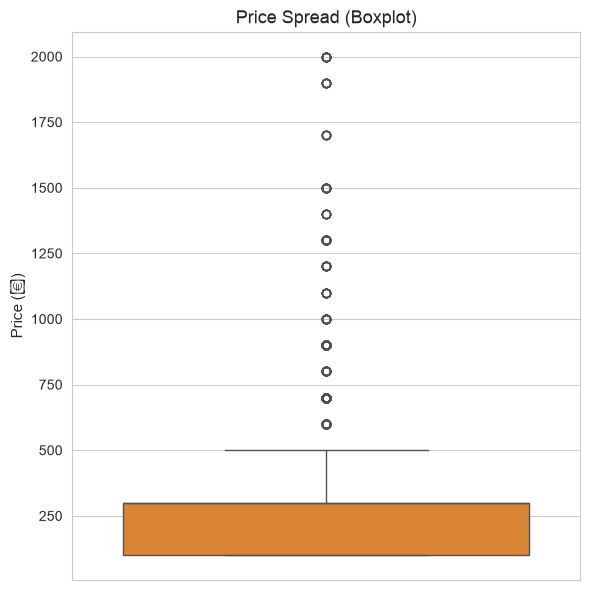

In [8]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=df['price_numeric'], color='#F58518')
plt.title('Price Spread (Boxplot)')
plt.ylabel('Price (₹)')
plt.tight_layout()
plt.show()


**Observation:** Prices are heavily concentrated in the ₹100-400 range,
which is what is expected for a mostly casual-dining dataset. The boxplot
shows a long tail of expensive restaurants going up to ₹2000, but these are
clearly the minority

**Business Insight:** Bengaluru's restaurant scene ( in this dataset )
is dominated by budget-to-mid-range places. 


### Reviews Count Distribution


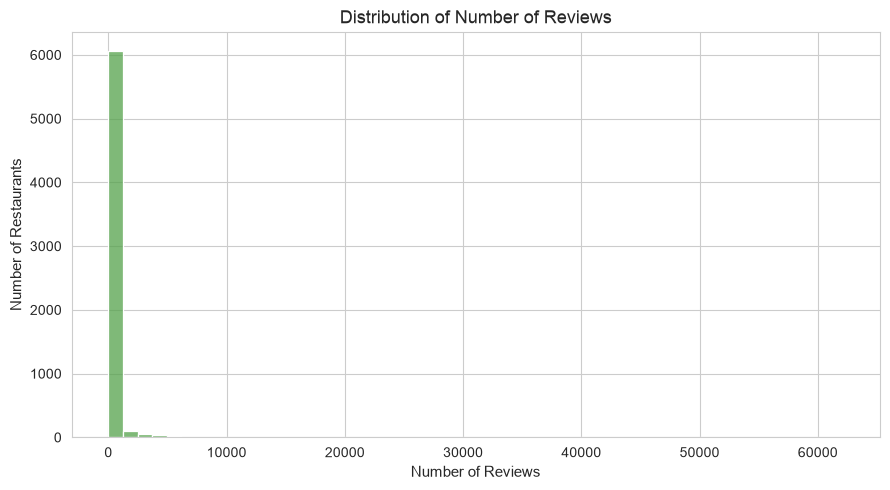

In [9]:
plt.figure(figsize=(9, 5))
sns.histplot(df['reviewsCount'], bins=50, color='#54A24B', kde=False)
plt.title('Distribution of Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()


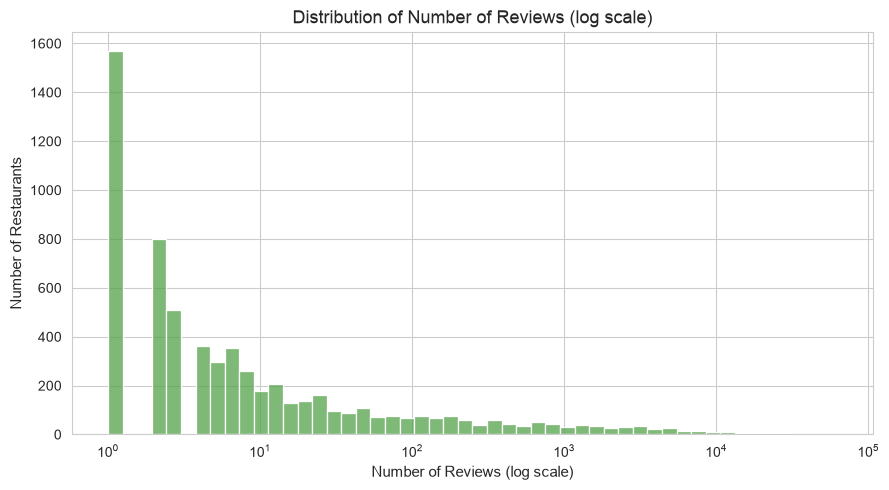

count     6335.000000
mean       277.784373
std       1767.427394
min          1.000000
25%          2.000000
50%          4.000000
75%         20.000000
max      62149.000000
Name: reviewsCount, dtype: float64


In [10]:
# log scale version, since the raw distribution is extremely skewed
plt.figure(figsize=(9, 5))
sns.histplot(df['reviewsCount'], bins=50, color='#54A24B', kde=False, log_scale=True)
plt.title('Distribution of Number of Reviews (log scale)')
plt.xlabel('Number of Reviews (log scale)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()
print(df['reviewsCount'].describe())


**Observation:** The plain histogram is basically unreadable because a
handful of restaurants have tens of thousands of reviews while most have
under 20. On the log scale it's clearer — the median is only 4 reviews,
which means the "typical" restaurant in this dataset is a small, mostly
unreviewed place, and the popular chains are the exception, not the rule.

**Business Insight:** A small number of very popular restaurants are pulling
the average review count way up. Any analysis using the mean review count
would be misleading here — median is a much better representative number for
this dataset.


### Correlation Heatmap


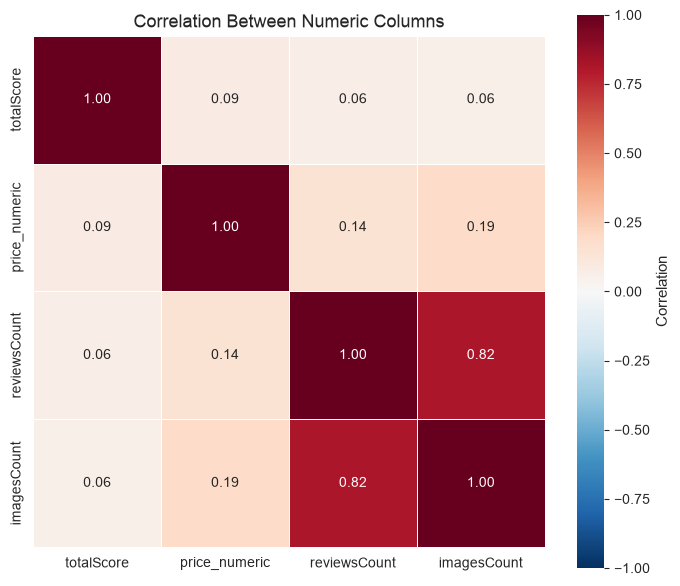

In [11]:
numeric_cols = ['totalScore', 'price_numeric', 'reviewsCount', 'imagesCount']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Numeric Columns')
plt.tight_layout()
plt.show()


**Observation:** `reviewsCount`
and `imagesCount` are the highest at around 0.82, which shows popular
restaurants naturally end up with more photos uploaded by customers too.
Everything else involving `totalScore` (price, reviews, images) is weak,
mostly in the 0.06-0.09 range.

**Business Insight:** Rating doesn't seem to move much with price or
popularity on its own. This tells us that a model trying to predict rating just from
price/reviews/images alone is not going to have much to work with, and the
service-related features (parking, delivery, etc.) might matter more than
the purely numeric ones.


### Price vs Rating


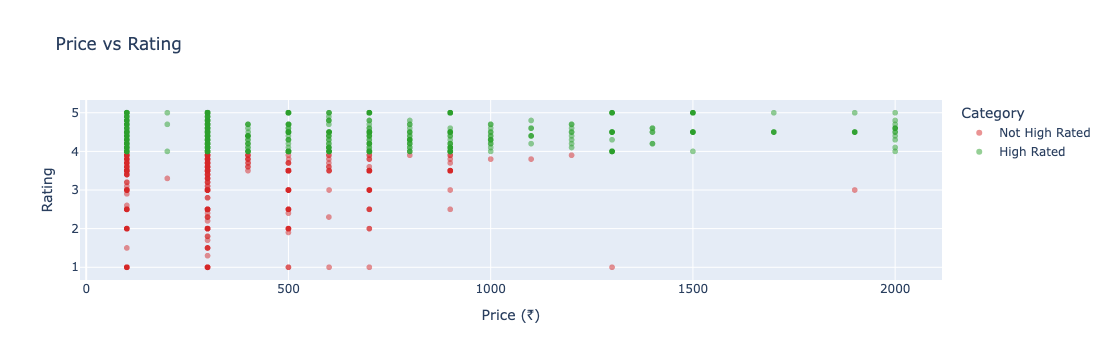

In [12]:
fig = px.scatter(df, x='price_numeric', y='totalScore',
                  color=df['High Rated'].map({1: 'High Rated', 0: 'Not High Rated'}),
                  hover_name='title',
                  title='Price vs Rating',
                  labels={'price_numeric': 'Price (₹)', 'totalScore': 'Rating',
                          'color': 'Category'},
                  opacity=0.5,
                  color_discrete_map={'High Rated': '#2CA02C', 'Not High Rated': '#D62728'})
fig.show()


**Observation:** There's no clean line where price predicts rating.
Expensive restaurants are scattered across the whole rating range, same as
the cheap ones.

**Business Insight:** Expensive doesn't automatically mean better rated.
Customers seem to be rating restaurants based on something other than just
price — probably service, food quality, or consistency, which this dataset
doesn't directly capture.


### Bubble Chart — Reviews, Rating and Price Together


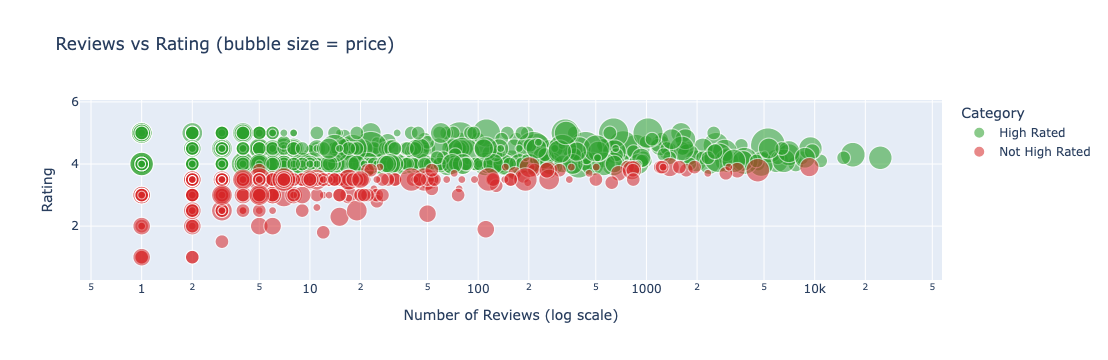

In [13]:

sample_df = df.sample(n=min(1500, len(df)), random_state=42)

fig = px.scatter(sample_df, x='reviewsCount', y='totalScore',
                  size='price_numeric', color=sample_df['High Rated'].map({1: 'High Rated', 0: 'Not High Rated'}),
                  hover_name='title', log_x=True, size_max=35,
                  title='Reviews vs Rating (bubble size = price)',
                  labels={'reviewsCount': 'Number of Reviews (log scale)', 'totalScore': 'Rating',
                          'color': 'Category'},
                  color_discrete_map={'High Rated': '#2CA02C', 'Not High Rated': '#D62728'},
                  opacity=0.55)
fig.show()


**Observation:** The restaurants with a large number of reviews (right
side of the chart) tend to sit more consistently in the high-rated zone.

**Business Insight:** Getting more reviews seems to go together with
being rated well, more so than price does. This might say that popular places get rated more generously.


### Density Heatmap — Price vs Rating


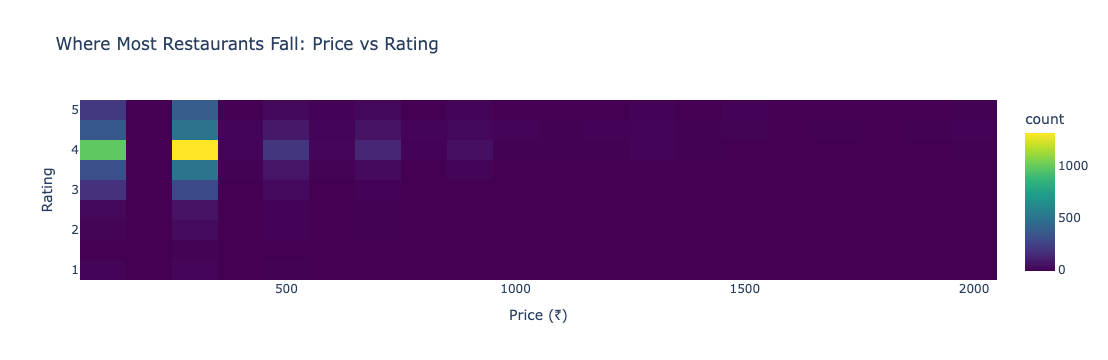

In [14]:
fig = px.density_heatmap(df, x='price_numeric', y='totalScore',
                          nbinsx=20, nbinsy=15,
                          title='Where Most Restaurants Fall: Price vs Rating',
                          labels={'price_numeric': 'Price (₹)', 'totalScore': 'Rating'},
                          color_continuous_scale='Viridis')
fig.show()


**Observation:** The darkest (most populated) patch sits around
₹100-300 and rating 3.5-4.5. That's basically confirming what the earlier
histograms already showed — the bulk of the dataset is budget restaurants
clustered around an average-to-good rating.

**Business Insight:** If someone were opening a new budget restaurant, this
is the "crowd" they'd be competing against — a large number of similarly
priced places already sitting in the 3.5-4.5 rating band.


### Contour Plot — Price, Reviews and Rating


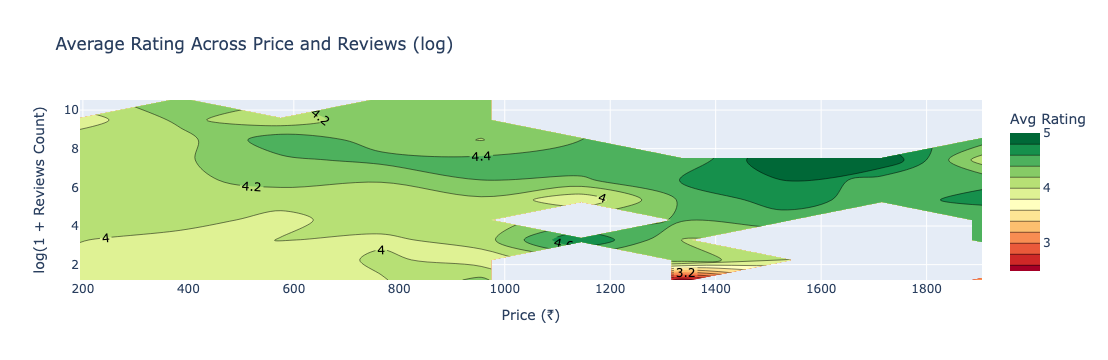

In [15]:
# Building a grid of average rating across price and reviewsCount bins,
# then plotting it as a contour so we can see how rating shifts across
# both variables at once instead of just one at a time.

df['price_bin'] = pd.cut(df['price_numeric'], bins=10)
df['reviews_bin'] = pd.cut(np.log1p(df['reviewsCount']), bins=10)

pivot = df.pivot_table(index='reviews_bin', columns='price_bin',
                        values='totalScore', aggfunc='mean', observed=False)

price_mid = [interval.mid for interval in pivot.columns]
reviews_mid = [interval.mid for interval in pivot.index]

fig = go.Figure(data=go.Contour(
    z=pivot.values,
    x=price_mid,
    y=reviews_mid,
    colorscale='RdYlGn',
    contours=dict(showlabels=True),
    colorbar=dict(title='Avg Rating')
))
fig.update_layout(title='Average Rating Across Price and Reviews (log)',
                   xaxis_title='Price (₹)', yaxis_title='log(1 + Reviews Count)')
fig.show()


**Observation:** The greener (higher rating) regions show up more
towards the upper part of the chart, where the log-reviews value is higher
— basically confirming the bubble chart finding again.

**Business Insight:** Out of price and review volume, review volume looks
like the stronger signal for predicting a good rating. A restaurant that's been reviewed a lot and still holds a
good rating has proven itself over more customers, whereas one review at 5
stars doesn't mean much.


### Average Rating by Cuisine


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/241540163.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index, palette='Blues_r')


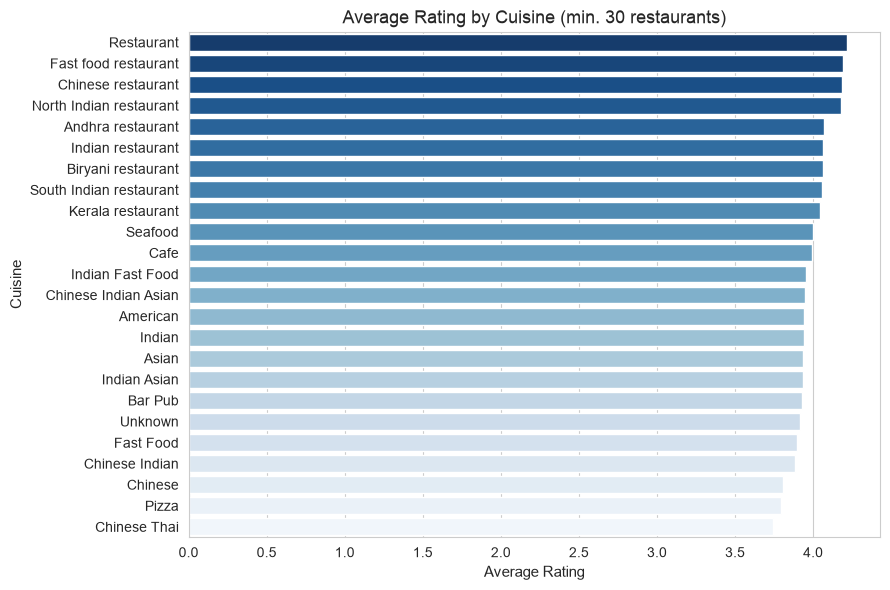

In [16]:
# only looking at cuisines with a reasonable sample size, otherwise a
# cuisine with 2 restaurants and a lucky 5-star average would be misleading
cuisine_counts = df['cuisine'].value_counts()
valid_cuisines = cuisine_counts[cuisine_counts >= 30].index

cuisine_rating = (df[df['cuisine'].isin(valid_cuisines)]
                   .groupby('cuisine')['totalScore']
                   .mean()
                   .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
sns.barplot(x=cuisine_rating.values, y=cuisine_rating.index, palette='Blues_r')
plt.title('Average Rating by Cuisine (min. 30 restaurants)')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


**Observation:** "Restaurant" (multi-cuisine
places) and Fast Food restaurants come out on top, while Pizza and Chinese
Thai sit at the bottom of this list. The gap between the highest and lowest
isn't huge though — roughly 4.2 vs 3.7, so cuisine on its own isn't a massive
influencing factor.

**Business Insight:** Cuisine type has some effect on rating but it's not
the dominant factor.


### Average Rating by Neighbourhood


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/349807431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=neigh_rating.values, y=neigh_rating.index, palette='Purples_r')


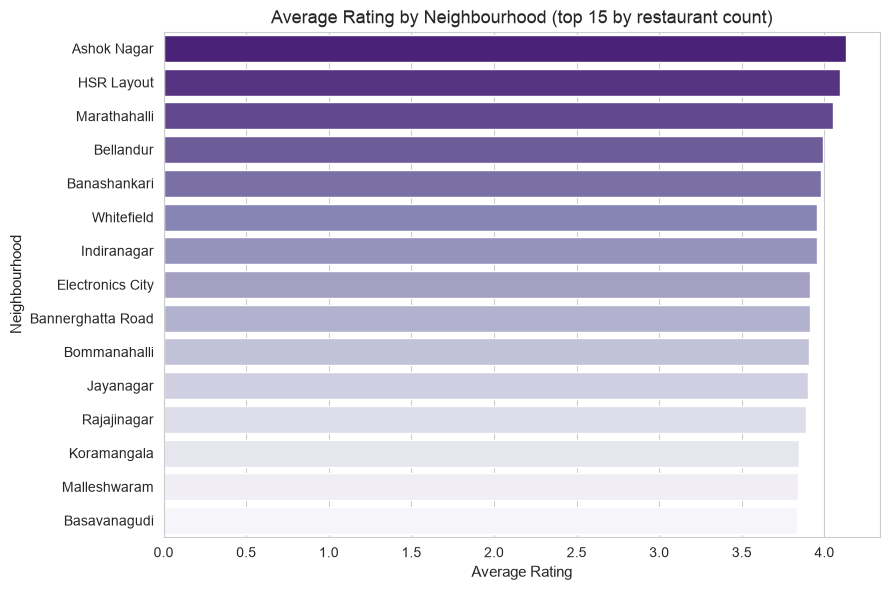

In [17]:
neighbourhood_counts = df['neighborhood'].value_counts()
top_neighbourhoods = neighbourhood_counts.head(15).index

neigh_rating = (df[df['neighborhood'].isin(top_neighbourhoods)]
                 .groupby('neighborhood')['totalScore']
                 .mean()
                 .sort_values(ascending=False))

plt.figure(figsize=(9, 6))
sns.barplot(x=neigh_rating.values, y=neigh_rating.index, palette='Purples_r')
plt.title('Average Rating by Neighbourhood (top 15 by restaurant count)')
plt.xlabel('Average Rating')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


**Observation:** HSR Layout and Marathahalli come out slightly ahead
of the rest, while Basavanagudi and Malleshwaram sit a bit lower. Again, the
spread is small (around 3.83 to 4.10), so it's not like one neighbourhood is
massively better than another — this is a mild effect.

**Business Insight:** Location does seem to matter a little for ratings, but
not enough that it should be the only factor someone considers before
opening a restaurant somewhere.


### Average Rating by Price Category


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3965500898.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=price_cat_rating.index, y=price_cat_rating.values, palette='Oranges_r')


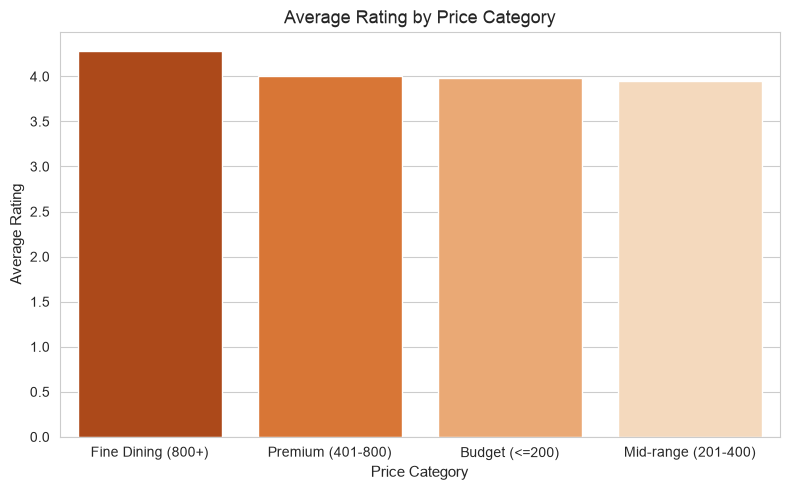

In [18]:
price_cat_rating = (df.groupby('price_category')['totalScore']
                     .mean()
                     .sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=price_cat_rating.index, y=price_cat_rating.values, palette='Oranges_r')
plt.title('Average Rating by Price Category')
plt.xlabel('Price Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


**Observation:** Fine Dining restaurants (₹800+) have the highest
average rating at around 4.28, clearly ahead of the other three which are around 3.95-4.0.

**Business Insight:** This is a bit different from what the price vs rating
scatter plot suggested at first . It seems like price alone doesn't
predict rating across the whole range, but restaurants right at the very top
end of pricing genuinely do perform a bit better on average — maybe because
that price point comes with an expectation of quality that these places are
actually meeting.


### Treemap — Cuisine and High Rated Share


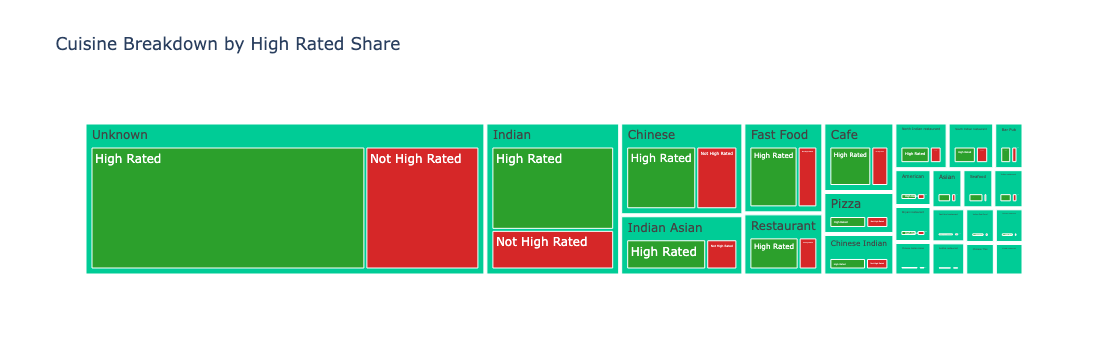

In [19]:
treemap_df = df[df['cuisine'].isin(valid_cuisines)].copy()
treemap_df['High Rated Label'] = treemap_df['High Rated'].map({1: 'High Rated', 0: 'Not High Rated'})

fig = px.treemap(treemap_df, path=['cuisine', 'High Rated Label'],
                  title='Cuisine Breakdown by High Rated Share',
                  color='High Rated Label',
                  color_discrete_map={'High Rated': '#2CA02C', 'Not High Rated': '#D62728'})
fig.show()


**Observation:** Bigger cuisine categories like Indian and Chinese take
up most of the treemap.

**Business Insight:** Being high rated isn't limited to any one cuisine —
it's spread fairly evenly.


### Sunburst Chart — Neighbourhood, Cuisine and High Rated


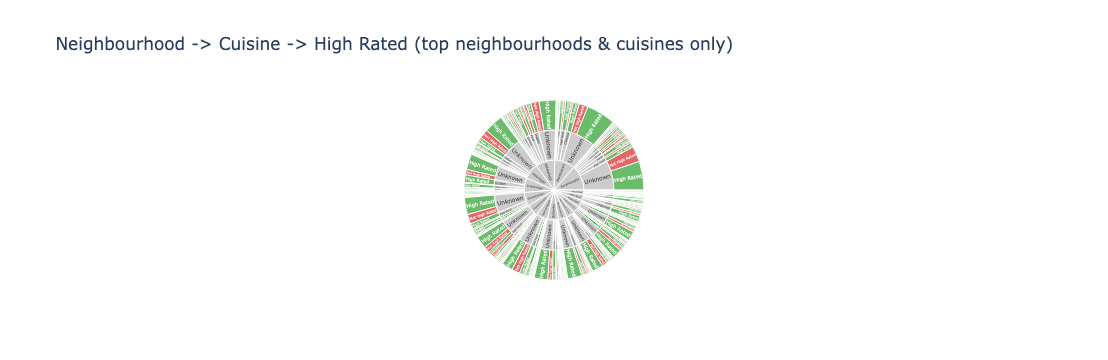

In [20]:
sunburst_df = df[df['neighborhood'].isin(top_neighbourhoods) & df['cuisine'].isin(valid_cuisines)].copy()
sunburst_df['High Rated Label'] = sunburst_df['High Rated'].map({1: 'High Rated', 0: 'Not High Rated'})

fig = px.sunburst(sunburst_df, path=['neighborhood', 'cuisine', 'High Rated Label'],
                   title='Neighbourhood -> Cuisine -> High Rated (top neighbourhoods & cuisines only)',
                   color='High Rated Label',
                   color_discrete_map={'High Rated': '#2CA02C', 'Not High Rated': '#D62728', '(?)': '#CCCCCC'})
fig.show()


**Observation:** This is restricted to the top 15 neighbourhoods and
cuisines with at least 30 restaurants. Within each neighbourhood-cuisine combination, green still tends to
dominate, similar to the treemap. Koramangala and Whitefield have the biggest
neighbourhood slices simply because they have the most restaurants overall.


### Scatter Matrix — Numeric Columns


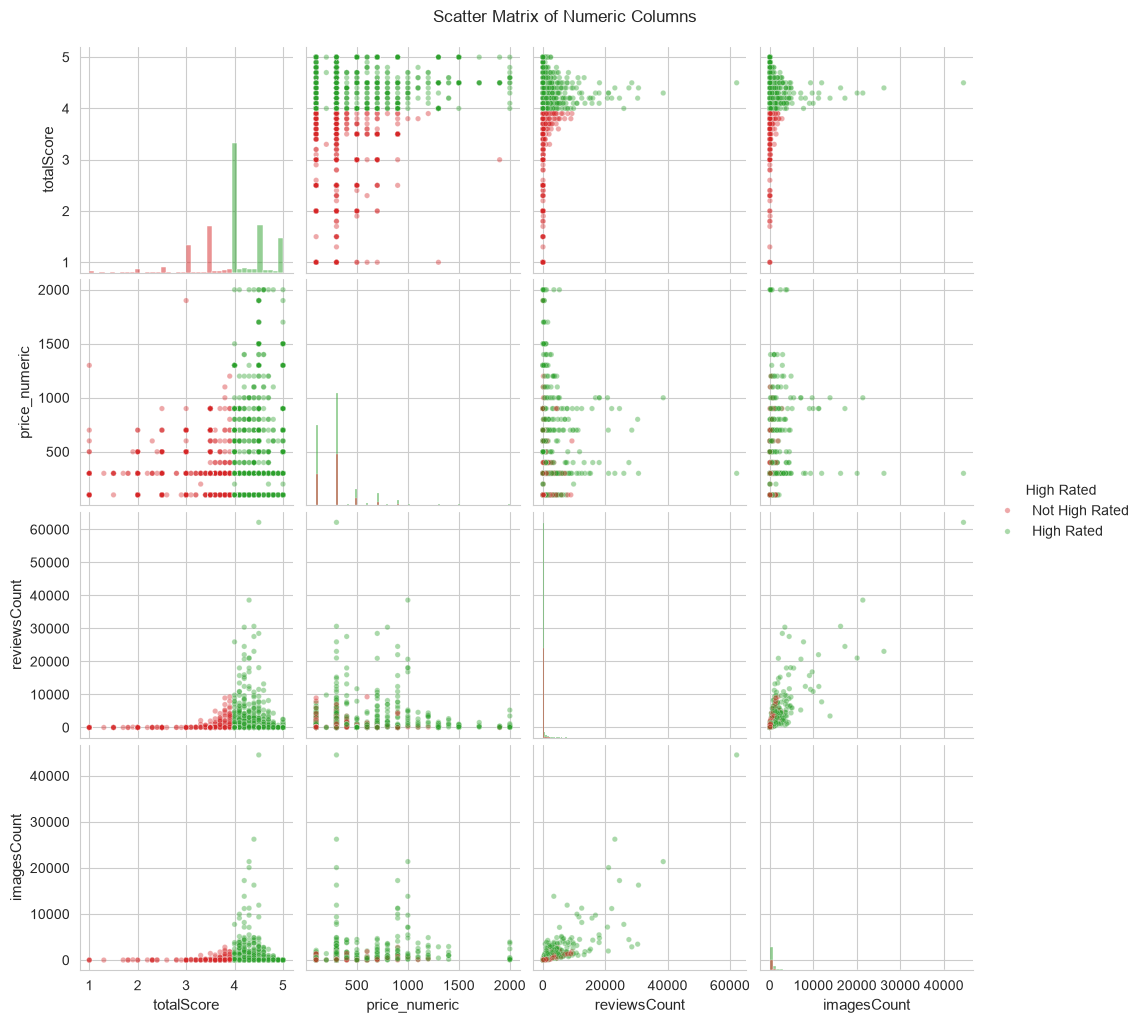

In [21]:
scatter_cols = ['totalScore', 'price_numeric', 'reviewsCount', 'imagesCount']
pairplot_df = df[scatter_cols].copy()
pairplot_df['High Rated'] = df['High Rated'].map({1: 'High Rated', 0: 'Not High Rated'})

sns.pairplot(pairplot_df, hue='High Rated', diag_kind='hist',
             palette={'High Rated': '#2CA02C', 'Not High Rated': '#D62728'},
             plot_kws={'alpha': 0.4, 's': 15})
plt.suptitle('Scatter Matrix of Numeric Columns', y=1.02)
plt.show()


**Observation:** This brings together everything from the earlier
individual scatter plots into one grid. The clearest linear-looking
relationship is between `reviewsCount` and `imagesCount` — everything
involving `totalScore` looks like more of a cloud than a line, confirming the
weak correlations from the heatmap earlier.


## Section 4: Service-wise Analysis


In [80]:


def service_quick_stats(data, col):
    """Returns average rating, median reviews, and % High Rated,
    split by whether the restaurant has this service or not."""
    grouped = data.groupby(col).agg(
        avg_rating=('totalScore', 'mean'),
        median_reviews=('reviewsCount', 'median'),
        pct_high_rated=('High Rated', 'mean'),
        count=('title', 'count')
    )
    grouped.index = grouped.index.map({0: 'No', 1: 'Yes'})
    grouped['pct_high_rated'] = (grouped['pct_high_rated'] * 100).round(1)
    grouped['avg_rating'] = grouped['avg_rating'].round(2)
    return grouped


def service_by_group(data, service_col, group_col, valid_groups, min_count=30):
    """% of restaurants offering a service, broken down by another
    categorical column (cuisine / neighbourhood / price category),
    restricted to groups with a reasonable sample size."""
    subset = data[data[group_col].isin(valid_groups)]
    result = subset.groupby(group_col)[service_col].mean().sort_values(ascending=False) * 100
    return result


print("Helper functions ready.")


Helper functions ready.


### 4.1 Delivery Analysis




In [23]:
delivery_stats = service_quick_stats(df, 'Delivery')
delivery_stats


,avg_rating,median_reviews,pct_high_rated,count
Delivery,,,,
No,3.94,3.0,70.2,5193
Yes,4.14,127.0,76.0,1142


**Observation:** Restaurants with Delivery have a slightly higher
average rating and a noticeably higher share of High Rated restaurants. The
median review count also jumps quite a bit for restaurants offering delivery
compared to those that don't.

**Business Insight:** Delivery isn't just an add-on here — it
looks tied to restaurants that are generally more visible and more reviewed,
which lines up with them also being rated better on average.


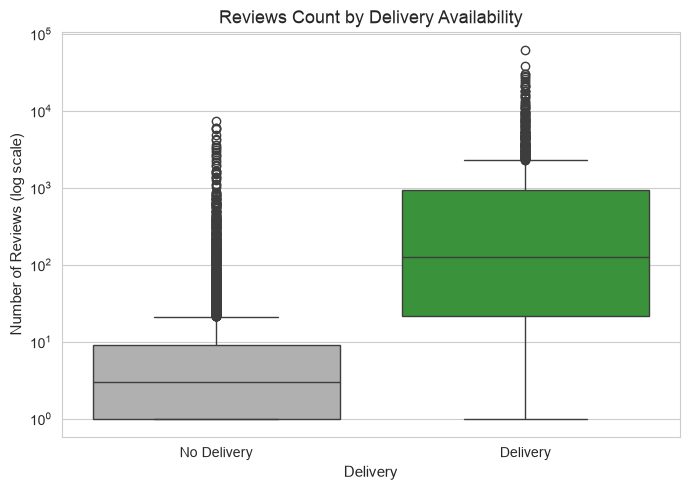

In [24]:
# Delivery vs Reviews Count (log scale, since reviewsCount is heavily skewed)
plot_df = df.copy()
plot_df['Delivery Label'] = plot_df['Delivery'].map({0: 'No Delivery', 1: 'Delivery'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='Delivery Label', y='reviewsCount',
            hue='Delivery Label', palette={'No Delivery': '#B0B0B0', 'Delivery': '#2CA02C'}, legend=False)
plt.yscale('log')
plt.title('Reviews Count by Delivery Availability')
plt.xlabel('Delivery')
plt.ylabel('Number of Reviews (log scale)')
plt.tight_layout()
plt.show()


**Observation:** The box for restaurants with Delivery is much higher
on the log scale than the one without. Restaurants without delivery are mostly clustered near just a
few reviews.

**Business Insight:** Delivery availability looks like one of the strongest
"popularity" signals among all the service features checked in this
notebook.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3859368092.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_by_price.index, y=delivery_by_price.values, palette='Greens_r')


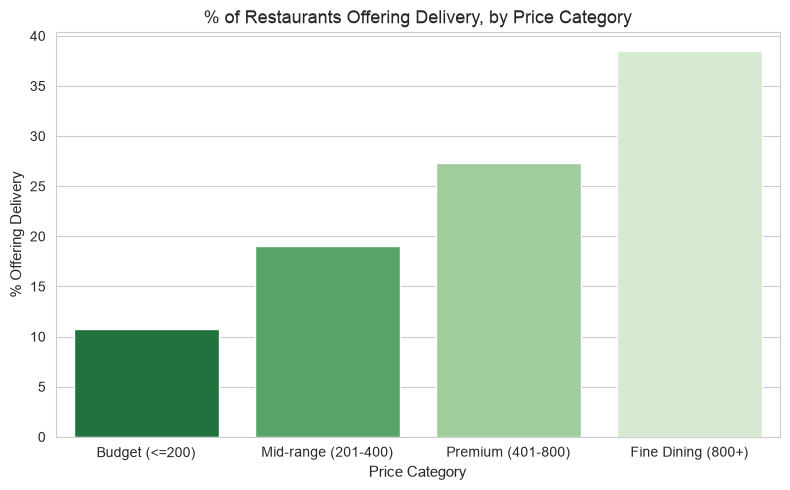

In [25]:
# Delivery vs Price Category - what share of each price bucket offers delivery
price_order = ['Budget (<=200)', 'Mid-range (201-400)', 'Premium (401-800)', 'Fine Dining (800+)']
delivery_by_price = (df.groupby('price_category')['Delivery'].mean() * 100).reindex(price_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=delivery_by_price.index, y=delivery_by_price.values, palette='Greens_r')
plt.title('% of Restaurants Offering Delivery, by Price Category')
plt.xlabel('Price Category')
plt.ylabel('% Offering Delivery')
plt.tight_layout()
plt.show()


**Observation:** Delivery goes up steadily as price goes up — Fine
Dining restaurants offer delivery almost 4x as often as Budget restaurants
do. 

**Business Insight:** Budget restaurants are actually under-offering
delivery relative to pricier restaurants — this could be an area budget
restaurant owners are missing out on, since delivery was linked to better
reviews and ratings above.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/2306593822.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_by_cuisine.head(10).values, y=delivery_by_cuisine.head(10).index, palette='Greens_r')


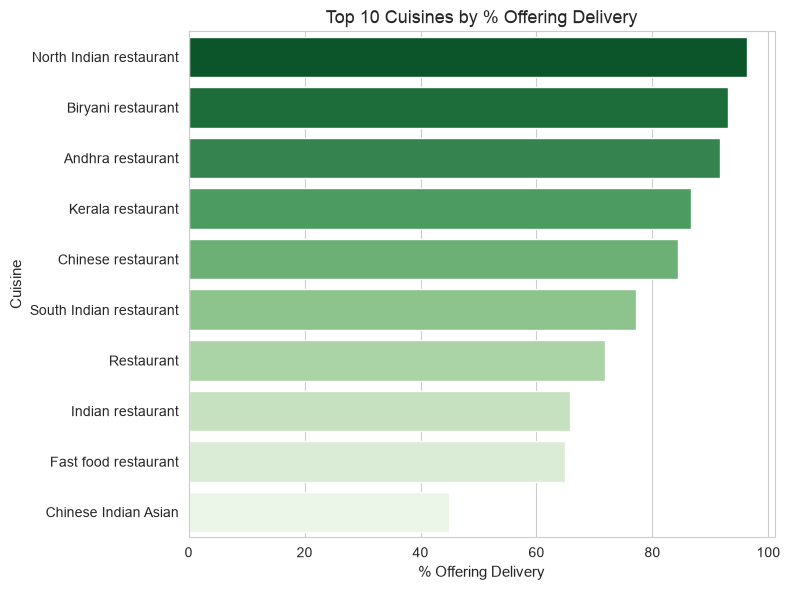

In [26]:
# Delivery vs Cuisine - top cuisines by delivery adoption
delivery_by_cuisine = service_by_group(df, 'Delivery', 'cuisine', valid_cuisines)

plt.figure(figsize=(8, 6))
sns.barplot(x=delivery_by_cuisine.head(10).values, y=delivery_by_cuisine.head(10).index, palette='Greens_r')
plt.title('Top 10 Cuisines by % Offering Delivery')
plt.xlabel('% Offering Delivery')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


**Observation:** North Indian, Biryani and Andhra restaurants offer
delivery the most (over 90% of them do). Pure "Restaurant"
labelled places and Fast Food are lower on this list, maybe because a chunk
of those are more dine-in focused already.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/4215029058.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_by_neigh.values, y=delivery_by_neigh.index, palette='Greens_r')


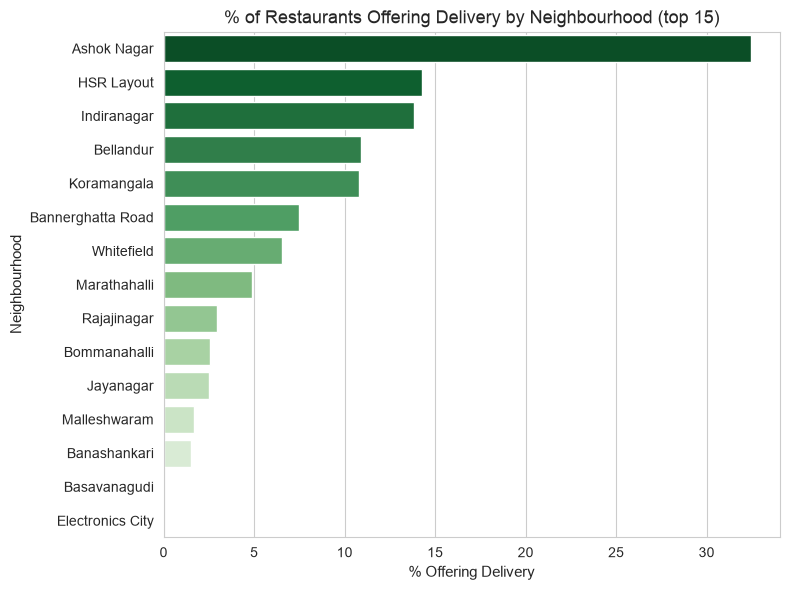

In [27]:
# Delivery vs Neighbourhood - top neighbourhoods by delivery adoption
delivery_by_neigh = service_by_group(df, 'Delivery', 'neighborhood', top_neighbourhoods)

plt.figure(figsize=(8, 6))
sns.barplot(x=delivery_by_neigh.values, y=delivery_by_neigh.index, palette='Greens_r')
plt.title('% of Restaurants Offering Delivery by Neighbourhood (top 15)')
plt.xlabel('% Offering Delivery')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


**Observation:** Ashok Nagar stands out with by far the highest
delivery adoption (roughly a third of restaurants there), while places like
Basavanagudi and Electronics City show almost none in this sample. Some of
this gap is probably just about how many restaurants each neighbourhood has
in the dataset.

**Business Insight:** For a delivery platform deciding where to focus
expansion or partner outreach, neighbourhoods with high restaurant density
but low current delivery adoption (like Koramangala at ~11%, which has the
most restaurants overall) could be an easier growth opportunity than chasing
neighbourhoods that already have high adoption.


### 4.2 Parking Analysis


In [28]:
parking_stats = service_quick_stats(df, 'Parking')
parking_stats


,avg_rating,median_reviews,pct_high_rated,count
Parking,,,,
No,3.92,3.0,69.1,5076
Yes,4.21,174.0,80.2,1259


**Observation:** Same pattern as Delivery — restaurants with Parking
have a clearly higher average rating, a big jump in median reviews, and a
noticeably higher % High Rated (80% vs 69%).


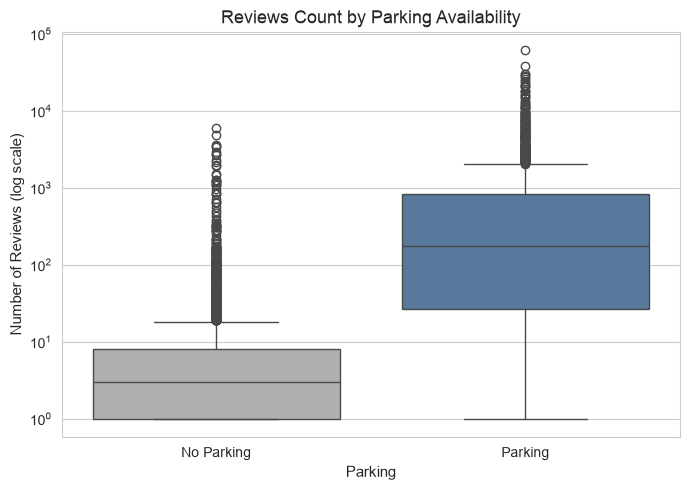

In [29]:
plot_df = df.copy()
plot_df['Parking Label'] = plot_df['Parking'].map({0: 'No Parking', 1: 'Parking'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='Parking Label', y='reviewsCount',
            hue='Parking Label', palette={'No Parking': '#B0B0B0', 'Parking': '#4C78A8'}, legend=False)
plt.yscale('log')
plt.title('Reviews Count by Parking Availability')
plt.xlabel('Parking')
plt.ylabel('Number of Reviews (log scale)')
plt.tight_layout()
plt.show()


**Observation:** Just like Delivery, the "has Parking" box sits much
higher on the log scale — parking seems tied to restaurants that get
reviewed a lot more.


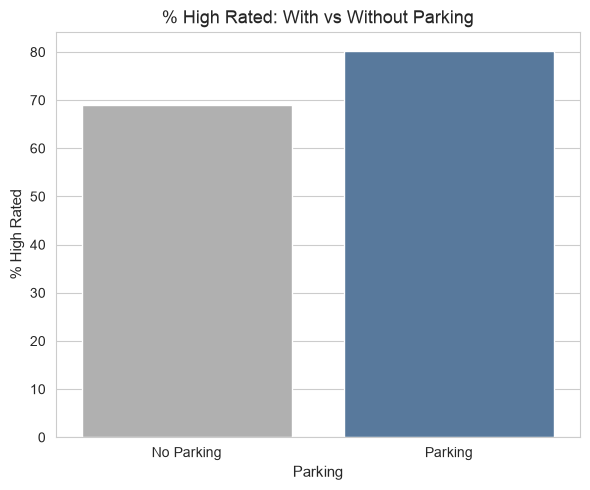

In [81]:
# Parking vs High Rated 
parking_high_rated = (df.groupby('Parking')['High Rated'].mean() * 100)
parking_high_rated.index = parking_high_rated.index.map({0: 'No Parking', 1: 'Parking'})

plt.figure(figsize=(6, 5))
sns.barplot(x=parking_high_rated.index, y=parking_high_rated.values,
            hue=parking_high_rated.index,
            palette={'No Parking': '#B0B0B0', 'Parking': '#4C78A8'}, legend=False)
plt.title('% High Rated: With vs Without Parking')
plt.xlabel('Parking')
plt.ylabel('% High Rated')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/4088633284.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parking_by_cuisine.head(10).values, y=parking_by_cuisine.head(10).index, palette='Blues_r')


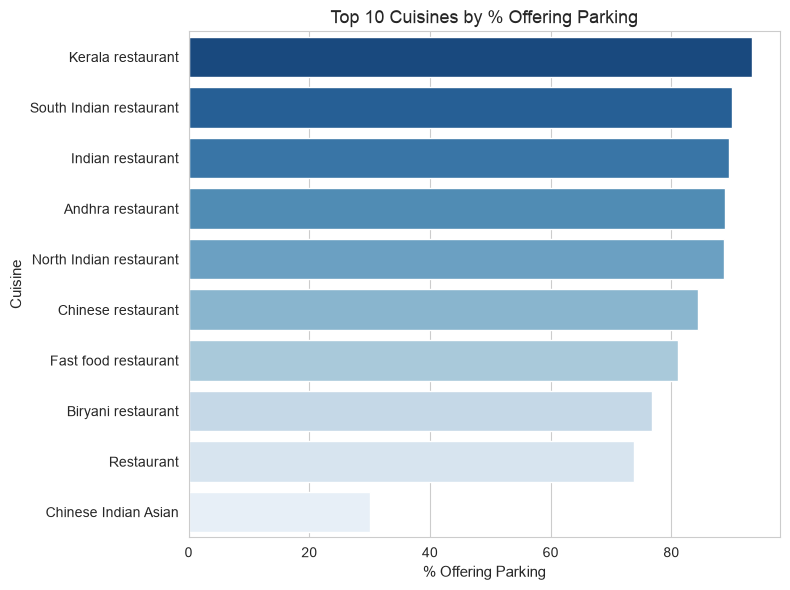

In [31]:
# Parking across cuisines
parking_by_cuisine = service_by_group(df, 'Parking', 'cuisine', valid_cuisines)

plt.figure(figsize=(8, 6))
sns.barplot(x=parking_by_cuisine.head(10).values, y=parking_by_cuisine.head(10).index, palette='Blues_r')
plt.title('Top 10 Cuisines by % Offering Parking')
plt.xlabel('% Offering Parking')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/1534385403.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=parking_by_neigh.values, y=parking_by_neigh.index, palette='Blues_r')


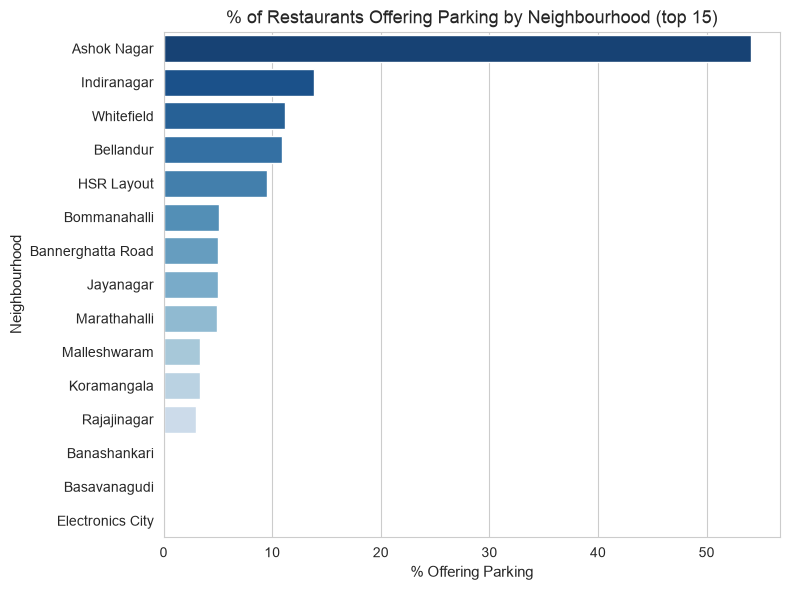

In [32]:
# Parking across neighbourhoods
parking_by_neigh = service_by_group(df, 'Parking', 'neighborhood', top_neighbourhoods)

plt.figure(figsize=(8, 6))
sns.barplot(x=parking_by_neigh.values, y=parking_by_neigh.index, palette='Blues_r')
plt.title('% of Restaurants Offering Parking by Neighbourhood (top 15)')
plt.xlabel('% Offering Parking')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


**Observation:** Kerala, South Indian and Indian restaurants lead in
parking availability, while Ashok Nagar again tops the neighbourhood list by
a wide margin, similar to what showed up for Delivery.

**Business Insight:** Parking does appear to improve customer satisfaction
in this dataset — it's one of the features with the widest rating gap
(4.21 vs 3.92) and the biggest jump in reviews. For a restaurant owner
deciding where to invest, parking looks like one of the better returns among
the features checked here, though it's obviously not always physically
possible depending on the location.


### 4.3 Reservations Analysis



In [33]:
reservations_stats = service_quick_stats(df, 'Reservations')
reservations_stats


,avg_rating,median_reviews,pct_high_rated,count
Reservations,,,,
No,3.93,3.0,69.1,4864
Yes,4.12,48.0,78.6,1471


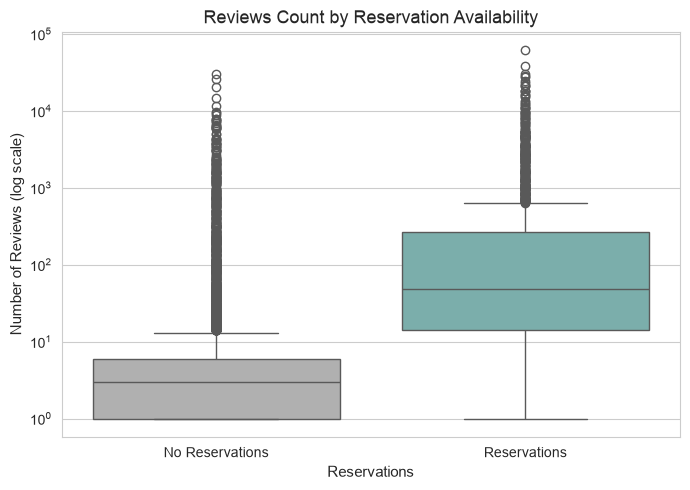

In [34]:
plot_df = df.copy()
plot_df['Reservations Label'] = plot_df['Reservations'].map({0: 'No Reservations', 1: 'Reservations'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='Reservations Label', y='reviewsCount',
            hue='Reservations Label', palette={'No Reservations': '#B0B0B0', 'Reservations': '#72B7B2'}, legend=False)
plt.yscale('log')
plt.title('Reviews Count by Reservation Availability')
plt.xlabel('Reservations')
plt.ylabel('Number of Reviews (log scale)')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/1595173896.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reservations_by_neigh.values, y=reservations_by_neigh.index, palette='BuGn_r')


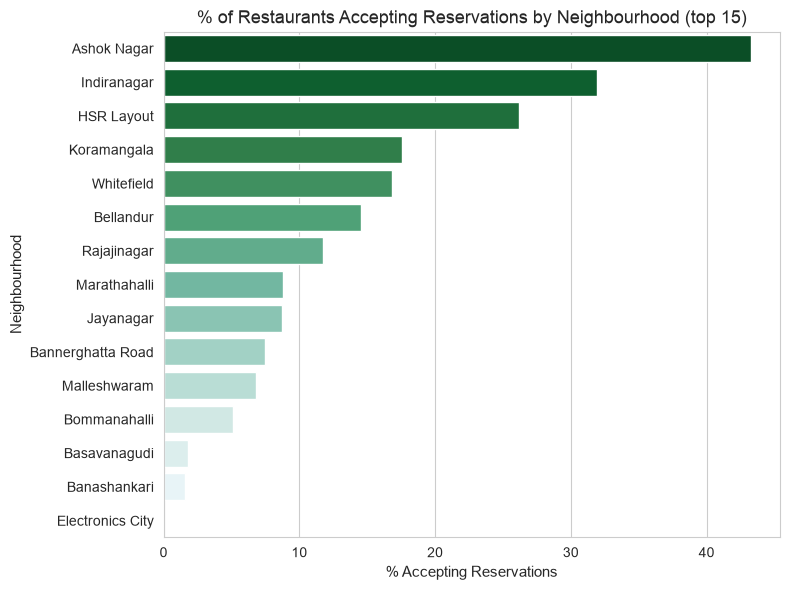

In [35]:
# Reservations vs Neighbourhood
reservations_by_neigh = service_by_group(df, 'Reservations', 'neighborhood', top_neighbourhoods)

plt.figure(figsize=(8, 6))
sns.barplot(x=reservations_by_neigh.values, y=reservations_by_neigh.index, palette='BuGn_r')
plt.title('% of Restaurants Accepting Reservations by Neighbourhood (top 15)')
plt.xlabel('% Accepting Reservations')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3763571507.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reservations_by_cuisine.head(10).values, y=reservations_by_cuisine.head(10).index, palette='BuGn_r')


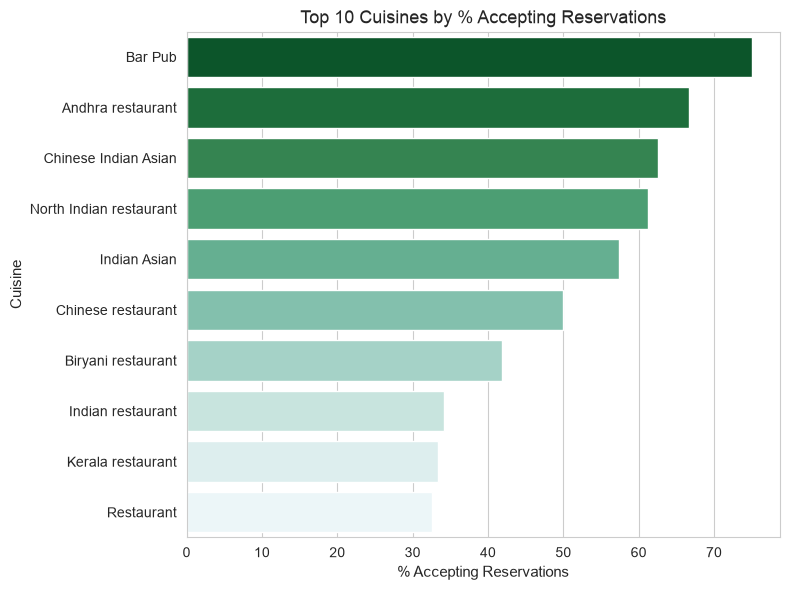

In [36]:
# Reservations vs Cuisine
reservations_by_cuisine = service_by_group(df, 'Reservations', 'cuisine', valid_cuisines)

plt.figure(figsize=(8, 6))
sns.barplot(x=reservations_by_cuisine.head(10).values, y=reservations_by_cuisine.head(10).index, palette='BuGn_r')
plt.title('Top 10 Cuisines by % Accepting Reservations')
plt.xlabel('% Accepting Reservations')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


**Observation:** "Bar Pub" and Andhra restaurants top the list for
accepting reservations, which for the Bar Pub category — those
places usually need to manage table availability more carefully than a quick
casual restaurant would. Reservations show the same general pattern as the
other features: higher rating (4.12 vs 3.93), higher % High Rated (79% vs
69%), and a big jump in review count.

**Business Insight:** Reservations appear to benefit cuisines that involve a
longer sit-down experience (bars, North Indian, Andhra) more than quick-service
style cuisines. 

### 4.4 Outdoor Seating Analysis


In [37]:
outdoor_stats = service_quick_stats(df, 'Outdoor Seating')
outdoor_stats


,avg_rating,median_reviews,pct_high_rated,count
Outdoor Seating,,,,
No,3.93,3.0,68.8,4640
Yes,4.11,46.0,78.0,1695


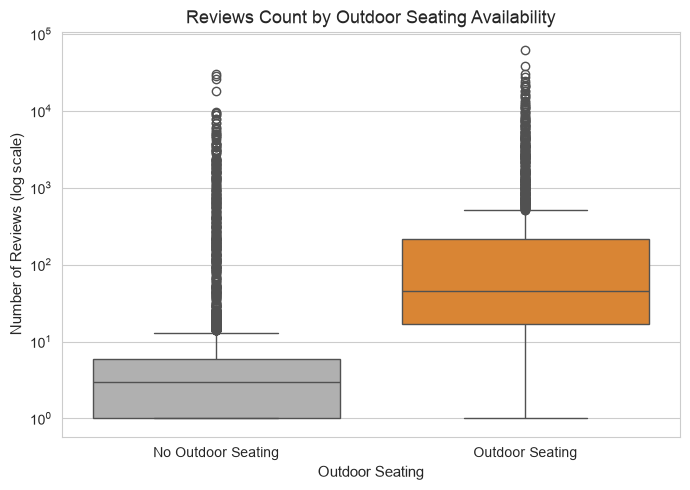

In [38]:
plot_df = df.copy()
plot_df['Outdoor Label'] = plot_df['Outdoor Seating'].map({0: 'No Outdoor Seating', 1: 'Outdoor Seating'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='Outdoor Label', y='reviewsCount',
            hue='Outdoor Label', palette={'No Outdoor Seating': '#B0B0B0', 'Outdoor Seating': '#F58518'}, legend=False)
plt.yscale('log')
plt.title('Reviews Count by Outdoor Seating Availability')
plt.xlabel('Outdoor Seating')
plt.ylabel('Number of Reviews (log scale)')
plt.tight_layout()
plt.show()


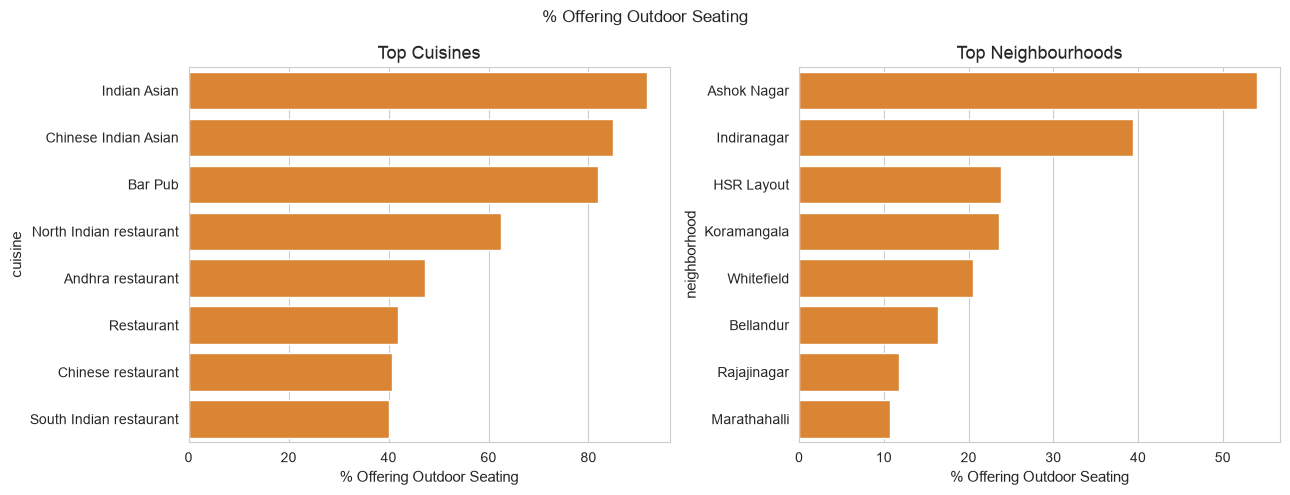

In [39]:
# Outdoor Seating vs Cuisine and Neighbourhood, side by side using subplots
outdoor_by_cuisine = service_by_group(df, 'Outdoor Seating', 'cuisine', valid_cuisines).head(8)
outdoor_by_neigh = service_by_group(df, 'Outdoor Seating', 'neighborhood', top_neighbourhoods).head(8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.barplot(x=outdoor_by_cuisine.values, y=outdoor_by_cuisine.index, color='#F58518', ax=axes[0])
axes[0].set_title('Top Cuisines')
axes[0].set_xlabel('% Offering Outdoor Seating')
sns.barplot(x=outdoor_by_neigh.values, y=outdoor_by_neigh.index, color='#F58518', ax=axes[1])
axes[1].set_title('Top Neighbourhoods')
axes[1].set_xlabel('% Offering Outdoor Seating')
fig.suptitle('% Offering Outdoor Seating')
plt.tight_layout()
plt.show()


**Observation:** Outdoor Seating shows the same general direction as
the other features — a rating change(4.11 vs 3.93) and a large jump in review
count for restaurants that have it. The cuisine and neighbourhood spread
looks broadly similar to what showed up for Delivery and Parking.

**Business Insight:** Outdoor Seating fits the same as the
rest of the service features — it's tied to more popular, slightly
higher-rated restaurants.


### 4.5 Takeout Analysis


In [40]:
takeout_stats = service_quick_stats(df, 'Takeout')
takeout_stats


,avg_rating,median_reviews,pct_high_rated,count
Takeout,,,,
No,3.93,3.0,69.8,4800
Yes,4.12,80.0,76.0,1535


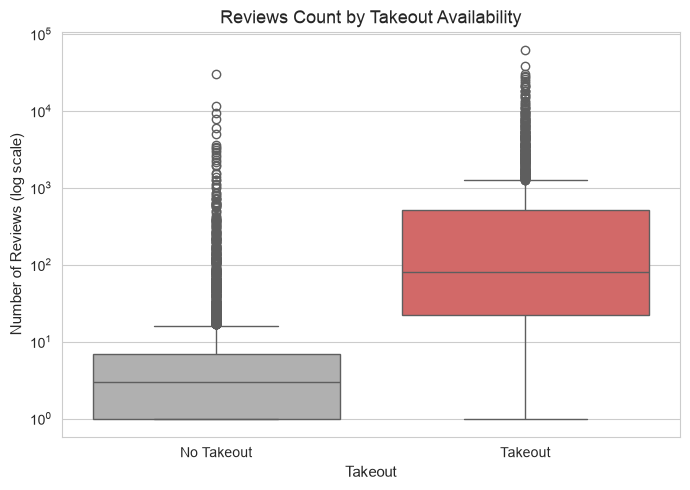

In [41]:
plot_df = df.copy()
plot_df['Takeout Label'] = plot_df['Takeout'].map({0: 'No Takeout', 1: 'Takeout'})

plt.figure(figsize=(7, 5))
sns.boxplot(data=plot_df, x='Takeout Label', y='reviewsCount',
            hue='Takeout Label', palette={'No Takeout': '#B0B0B0', 'Takeout': '#E45756'}, legend=False)
plt.yscale('log')
plt.title('Reviews Count by Takeout Availability')
plt.xlabel('Takeout')
plt.ylabel('Number of Reviews (log scale)')
plt.tight_layout()
plt.show()


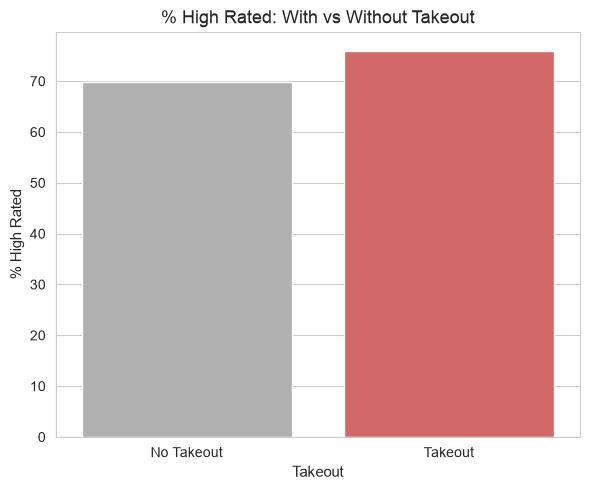

In [42]:
# Takeout vs High Rated
takeout_high_rated = (df.groupby('Takeout')['High Rated'].mean() * 100)
takeout_high_rated.index = takeout_high_rated.index.map({0: 'No Takeout', 1: 'Takeout'})

plt.figure(figsize=(6, 5))
sns.barplot(x=takeout_high_rated.index, y=takeout_high_rated.values,
            hue=takeout_high_rated.index,
            palette={'No Takeout': '#B0B0B0', 'Takeout': '#E45756'}, legend=False)
plt.title('% High Rated: With vs Without Takeout')
plt.xlabel('Takeout')
plt.ylabel('% High Rated')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/940159711.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=takeout_by_cuisine.head(10).values, y=takeout_by_cuisine.head(10).index, palette='Reds_r')


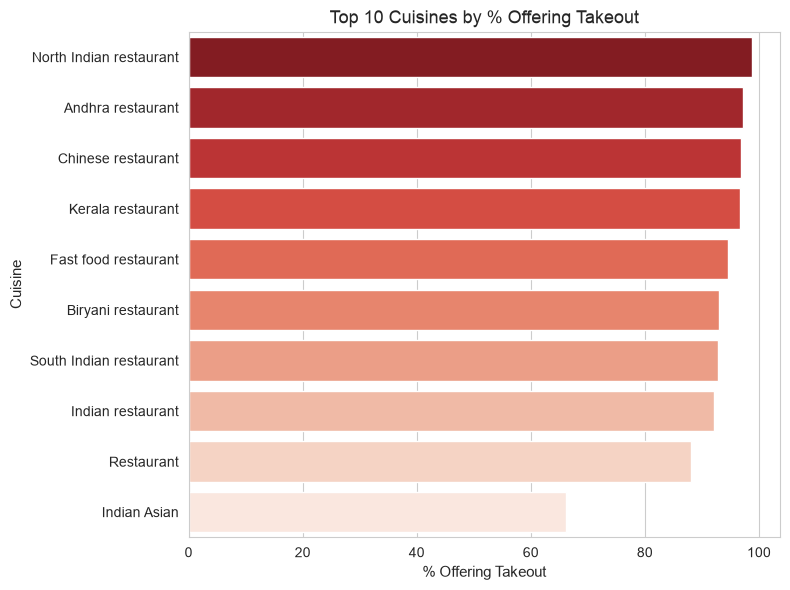

In [43]:
# Takeout vs Cuisine
takeout_by_cuisine = service_by_group(df, 'Takeout', 'cuisine', valid_cuisines)

plt.figure(figsize=(8, 6))
sns.barplot(x=takeout_by_cuisine.head(10).values, y=takeout_by_cuisine.head(10).index, palette='Reds_r')
plt.title('Top 10 Cuisines by % Offering Takeout')
plt.xlabel('% Offering Takeout')
plt.ylabel('Cuisine')
plt.tight_layout()
plt.show()


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/128325739.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=takeout_by_price.index, y=takeout_by_price.values, palette='Reds_r')


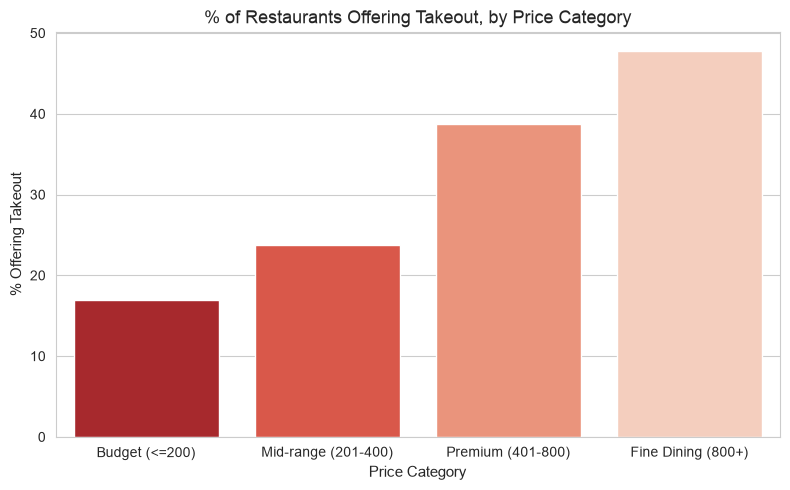

In [44]:
# Takeout vs Price Category
takeout_by_price = (df.groupby('price_category')['Takeout'].mean() * 100).reindex(price_order)

plt.figure(figsize=(8, 5))
sns.barplot(x=takeout_by_price.index, y=takeout_by_price.values, palette='Reds_r')
plt.title('% of Restaurants Offering Takeout, by Price Category')
plt.xlabel('Price Category')
plt.ylabel('% Offering Takeout')
plt.tight_layout()
plt.show()


**Observation:** Takeout follows the exact same pattern as Delivery —
adoption increases with price category (17% for Budget up to almost 48% for
Fine Dining).

**Business Insight:** Takeout and Delivery seem to go together — a
restaurant offering one is likely to offer the other, and both point
to the same : these convenience features are more common among
restaurants that are also more reviewed and slightly better rated.


### 4.6 Service Comparison — Does Having a Feature Change the Average Rating?


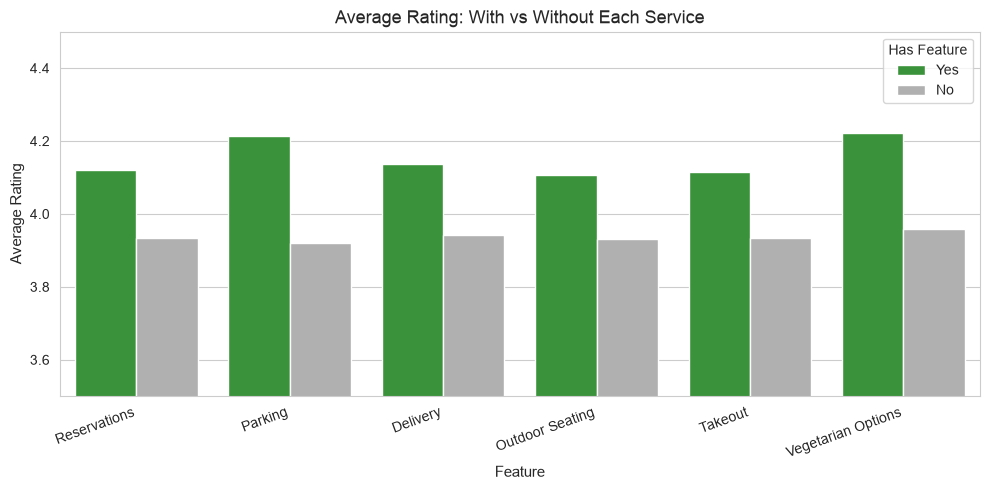

In [45]:
service_cols = ['Reservations', 'Parking', 'Delivery', 'Outdoor Seating',
                'Takeout', 'Vegetarian Options']

comparison_rows = []
for col in service_cols:
    comparison_rows.append({'Feature': col, 'Has Feature': 'Yes',
                             'Average Rating': df[df[col] == 1]['totalScore'].mean()})
    comparison_rows.append({'Feature': col, 'Has Feature': 'No',
                             'Average Rating': df[df[col] == 0]['totalScore'].mean()})

comparison_df = pd.DataFrame(comparison_rows)

plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Feature', y='Average Rating', hue='Has Feature',
            palette={'Yes': '#2CA02C', 'No': '#B0B0B0'})
plt.ylim(3.5, 4.5)
plt.title('Average Rating: With vs Without Each Service')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


**Observation:** For every single one of these six features, having it
is associated with a higher average rating than not having it. The gap is
biggest for Vegetarian Options and smallest for Delivery.

**Business Insight:** These extra services line up with better ratings
across the board, but that doesn't automatically mean the service *causes*
the higher rating — it might just be that restaurants which are more
customer-focused overall (better food, better service) also tend to invest
in offering these extra things.


### Boxplots — Rating Spread With and Without Each Feature


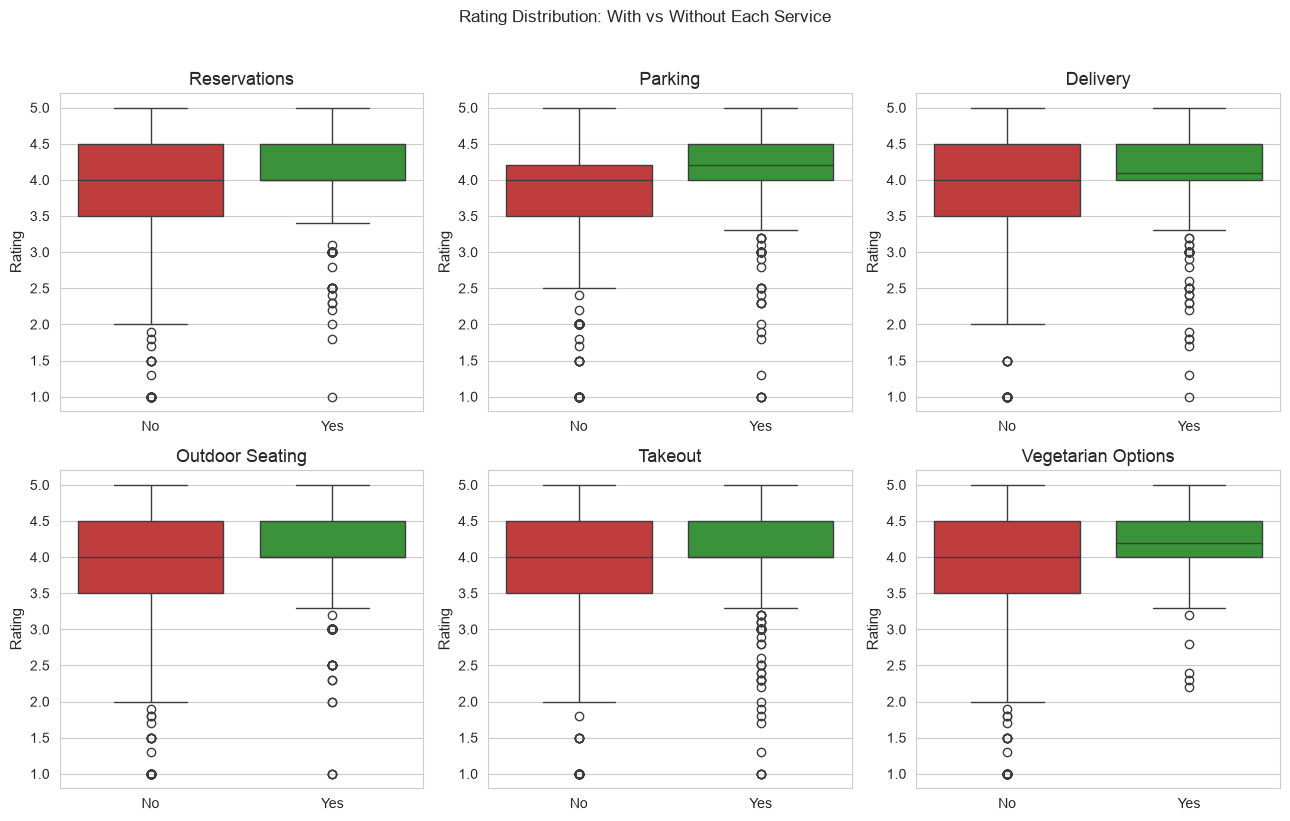

In [46]:
melted = df.melt(id_vars='totalScore', value_vars=service_cols,
                  var_name='Feature', value_name='Has Feature')
melted['Has Feature'] = melted['Has Feature'].map({1: 'Yes', 0: 'No'})

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.flatten()
for ax, feature in zip(axes, service_cols):
    subset = melted[melted['Feature'] == feature]
    sns.boxplot(data=subset, x='Has Feature', y='totalScore', hue='Has Feature',
                palette={'Yes': '#2CA02C', 'No': '#D62728'}, legend=False, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.set_ylabel('Rating')

fig.suptitle('Rating Distribution: With vs Without Each Service', y=1.02)
plt.tight_layout()
plt.show()


**Observation:** The medians for the "Yes" boxes are consistently a
little higher than the "No" boxes across all six features, which matches the
bar chart above. The "No" boxes are also a bit wider.

**Business Insight:** Restaurants with these features aren't just rated
higher on average, they're also more *consistent* — fewer of them fall into
the low-rating outlier zone.


### Pie Charts — Feature Distribution


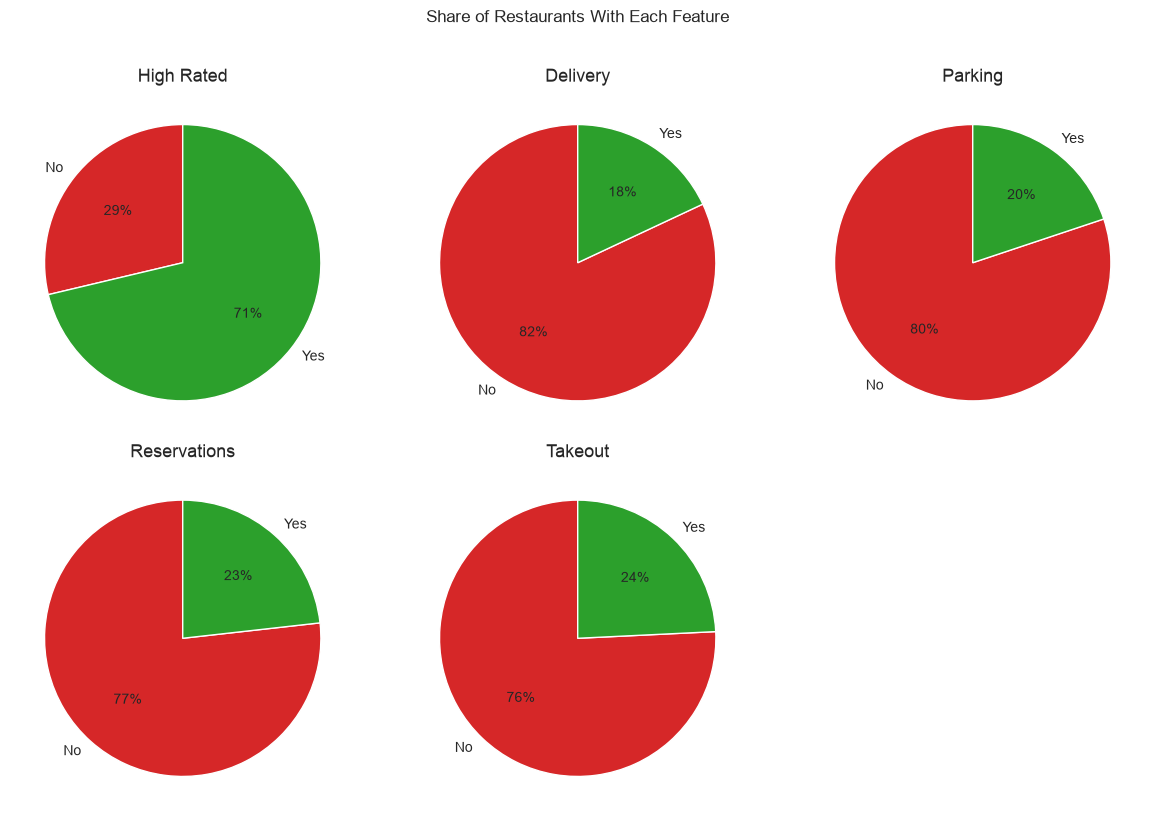

In [47]:
pie_cols = ['High Rated', 'Delivery', 'Parking', 'Reservations', 'Takeout']

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, pie_cols):
    counts = df[col].value_counts().sort_index()
    values = [counts.get(0, 0), counts.get(1, 0)]
    ax.pie(values, labels=['No', 'Yes'], autopct='%1.0f%%',
           colors=['#D62728', '#2CA02C'], startangle=90)
    ax.set_title(col)
axes[-1].axis('off')  # 6th subplot slot is unused

fig.suptitle('Share of Restaurants With Each Feature', y=1.02)
plt.tight_layout()
plt.show()


**Observation:** A little over 71% of restaurants in this dataset
count as "High Rated". Parking and Reservations show up in a fifth
to a quarter of restaurants, while Delivery and Takeout are somewhat less
common than expected for a food-delivery-heavy city like Bengaluru.

**Business Insight:** Since High Rated restaurants are already the majority
class — a model that just guesses "High Rated" for
everything would already be right most of the time, so accuracy alone won't
tell the full thing.


#### A Closer Look: Rating Gap, Reviews and High Rated % Together



In [48]:
service_comparison = pd.DataFrame({
    col: {
        'Avg Rating (Yes)': df[df[col] == 1]['totalScore'].mean(),
        'Avg Rating (No)': df[df[col] == 0]['totalScore'].mean(),
        'Rating Gap': df[df[col] == 1]['totalScore'].mean() - df[df[col] == 0]['totalScore'].mean(),
        'Avg Reviews (Yes)': df[df[col] == 1]['reviewsCount'].mean(),
        'Avg Reviews (No)': df[df[col] == 0]['reviewsCount'].mean(),
        'High Rated % (Yes)': df[df[col] == 1]['High Rated'].mean() * 100,
        'High Rated % (No)': df[df[col] == 0]['High Rated'].mean() * 100,
    }
    for col in service_cols
}).T.round(2)

service_comparison.sort_values('Rating Gap', ascending=False)


,Avg Rating (Yes),Avg Rating (No),Rating Gap,Avg Reviews (Yes),Avg Reviews (No),High Rated % (Yes),High Rated % (No)
Parking,4.21,3.92,0.29,1309.47,21.90,80.22,69.07
Vegetarian Options,4.22,3.96,0.26,2877.37,86.59,79.95,70.65
Delivery,4.14,3.94,0.20,1371.97,37.16,76.01,70.25
Reservations,4.12,3.93,0.19,852.25,104.05,78.59,69.08
Outdoor Seating,4.11,3.93,0.18,756.79,102.80,77.99,68.84
Takeout,4.12,3.93,0.18,1032.01,36.59,75.96,69.79


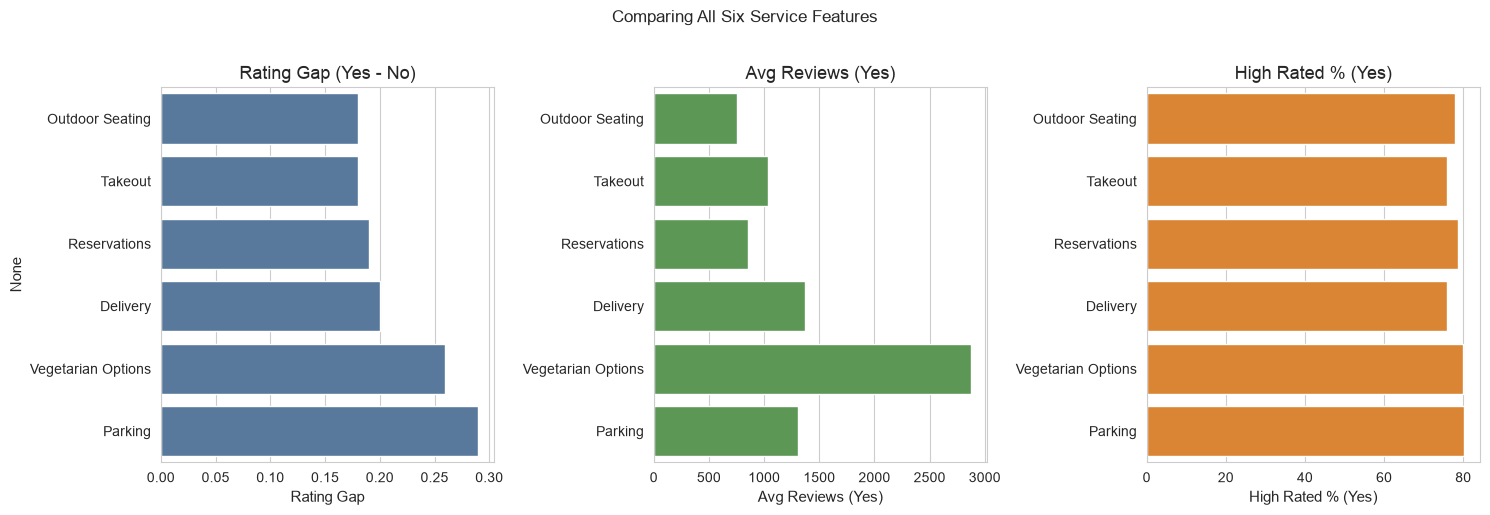

In [49]:
sorted_by_gap = service_comparison.sort_values('Rating Gap', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(x=sorted_by_gap['Rating Gap'], y=sorted_by_gap.index, color='#4C78A8', ax=axes[0])
axes[0].set_title('Rating Gap (Yes - No)')
sns.barplot(x=sorted_by_gap['Avg Reviews (Yes)'], y=sorted_by_gap.index, color='#54A24B', ax=axes[1])
axes[1].set_title('Avg Reviews (Yes)')
axes[1].set_ylabel('')
sns.barplot(x=sorted_by_gap['High Rated % (Yes)'], y=sorted_by_gap.index, color='#F58518', ax=axes[2])
axes[2].set_title('High Rated % (Yes)')
axes[2].set_ylabel('')

fig.suptitle('Comparing All Six Service Features', y=1.02)
plt.tight_layout()
plt.show()


**Observation:** Vegetarian Options has the biggest rating gap (0.26),
but Parking is close behind (0.29 — actually the largest) and also has by
far the highest average review count among restaurants that have it.
Delivery has the smallest rating gap of the six, even though it showed the
strongest popularity link in the earlier sections.

**Business Insight:** If the goal is specifically about **rating**, Parking
and Vegetarian Options look like the strongest levers among these six. If
the goal is about **popularity/reviews**, Parking and Delivery stand out
instead. So "which service matters most" actually depends on whether the
restaurant cares more about rating or about visibility .


### 4.7 Restaurant Popularity Analysis

Popularity and rating are not really the same thing — a restaurant can be
extremely popular (tons of reviews) without necessarily having the best
rating, or vice versa. 
**Building a popularity score:** Reviews count is the most direct signal of
popularity available in this dataset (more people reviewing = more people
actually visiting and engaging with the restaurant). Since `reviewsCount` is
extremely skewed (median of just 4, but a max over 60,000), a log transform
is applied first, then scaled to a 0-100 range. This keeps a single popular
outlier from dominating the whole score the way it would on the raw number.


In [50]:
# Popularity Score = min-max scaled log(1 + reviewsCount), rescaled to 0-100
log_reviews = np.log1p(df['reviewsCount'])
df['popularity_score'] = (log_reviews - log_reviews.min()) / (log_reviews.max() - log_reviews.min()) * 100

# Split into Low / Medium / High using terciles (roughly equal-sized groups)
low_cutoff, high_cutoff = df['popularity_score'].quantile([0.33, 0.66])

def popularity_label(score):
    if score <= low_cutoff:
        return 'Low'
    elif score <= high_cutoff:
        return 'Medium'
    else:
        return 'High'

df['popularity_category'] = df['popularity_score'].apply(popularity_label)

print(f"Low cutoff: {low_cutoff:.1f}, High cutoff: {high_cutoff:.1f}")
print(df['popularity_category'].value_counts())


Low cutoff: 3.9, High cutoff: 16.5
popularity_category
Low       2369
High      2081
Medium    1885
Name: count, dtype: int64


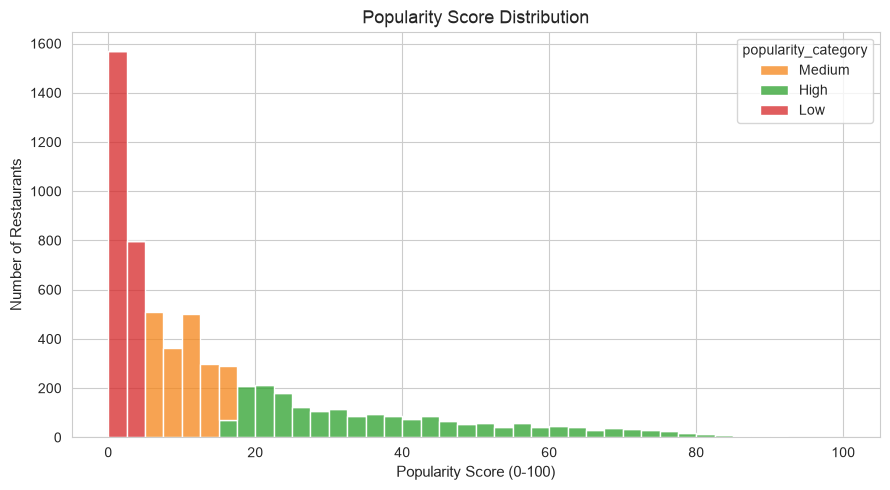

In [51]:
plt.figure(figsize=(9, 5))
sns.histplot(data=df, x='popularity_score', hue='popularity_category', bins=40,
             palette={'Low': '#D62728', 'Medium': '#F58518', 'High': '#2CA02C'},
             multiple='stack')
plt.title('Popularity Score Distribution')
plt.xlabel('Popularity Score (0-100)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()


**Observation:** The three groups come out fairly balanced by design but the histogram shows the "High" group
covers a wide range of scores while "Low" is more tightly packed near zero
.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/2005499010.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_rating.index, y=pop_rating.values, palette='viridis')


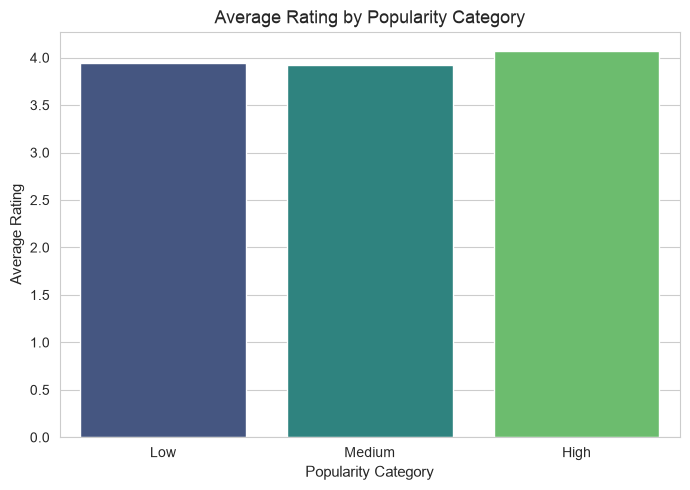

In [52]:
# Does popularity relate to rating?
pop_order = ['Low', 'Medium', 'High']
pop_rating = df.groupby('popularity_category')['totalScore'].mean().reindex(pop_order)

plt.figure(figsize=(7, 5))
sns.barplot(x=pop_rating.index, y=pop_rating.values, palette='viridis')
plt.title('Average Rating by Popularity Category')
plt.xlabel('Popularity Category')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()


**Observation:** The High popularity group does have the best average
rating (around 4.07), but Low (3.94) and Medium (3.92) are almost identical
to each other.

**Business Insight:** So popular restaurants tend to be a little better
rated. It looks like a restaurant needs to cross a fairly
high popularity threshold before it shows up in the ratings.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3015707405.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pop_price.index, y=pop_price.values, palette='Oranges')
/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3015707405.py:9: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Cellar/jupyterlab/4.5.9/libexec/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8377 (\N{INDIAN RUPEE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


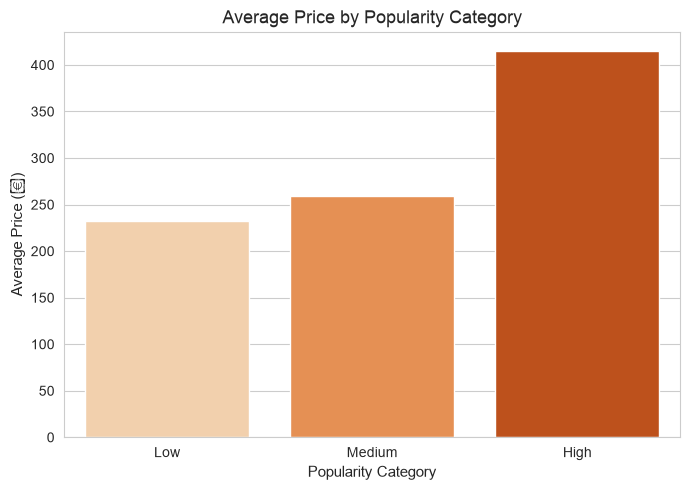

In [53]:
# Does price influence popularity more than it influences rating?
pop_price = df.groupby('popularity_category')['price_numeric'].mean().reindex(pop_order)

plt.figure(figsize=(7, 5))
sns.barplot(x=pop_price.index, y=pop_price.values, palette='Oranges')
plt.title('Average Price by Popularity Category')
plt.xlabel('Popularity Category')
plt.ylabel('Average Price (₹)')
plt.tight_layout()
plt.show()


**Observation:** Average price rises quite a bit more clearly across
popularity groups (₹232 -> ₹259 -> ₹415) than average rating did in the
previous chart. The jump from Medium to High popularity in price is much
bigger than the jump in rating was.

**Business Insight:** This suggests price is actually more tied to
popularity than it is to rating in this dataset — expensive restaurants
tend to be the ones getting reviewed a lot, more so than they tend to be
the ones rated highly. That's an important distinction: a high price tag
seems to buy visibility/reviews more reliably than it buys a better rating.


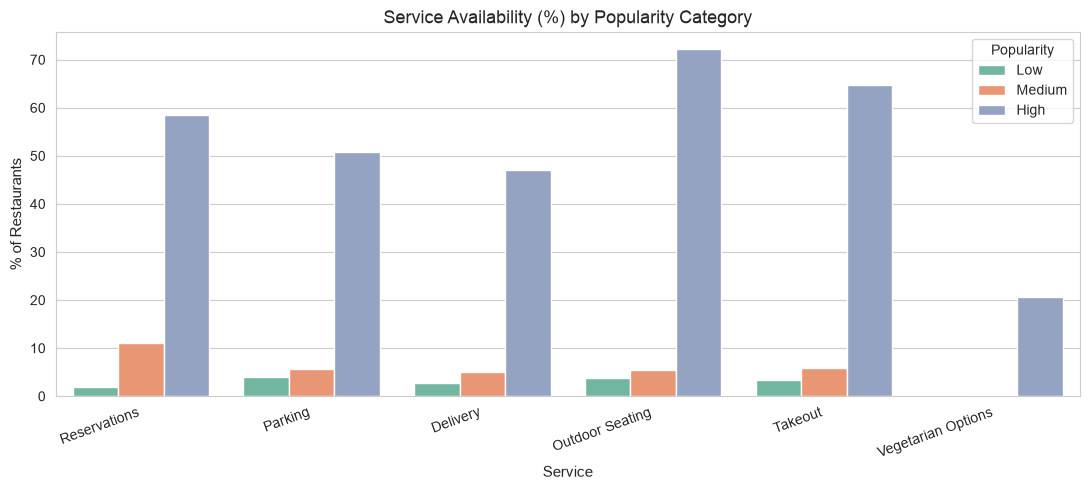

In [54]:
# Which services are most common among popular restaurants?
pop_services = df.groupby('popularity_category')[service_cols].mean().reindex(pop_order) * 100
pop_services_long = pop_services.reset_index().melt(id_vars='popularity_category',
                                                      var_name='Service', value_name='pct')

plt.figure(figsize=(11, 5))
sns.barplot(data=pop_services_long, x='Service', y='pct', hue='popularity_category',
            hue_order=pop_order, palette='Set2')
plt.title('Service Availability (%) by Popularity Category')
plt.xlabel('Service')
plt.ylabel('% of Restaurants')
plt.xticks(rotation=20, ha='right')
plt.legend(title='Popularity')
plt.tight_layout()
plt.show()


**Observation:** Every single service feature is far more common in the
High popularity group than in Low or Medium — Delivery and Reservations show
the biggest jumps, going from close to nothing in the Low group to roughly
half of restaurants in the High group.

**Business Insight:**  These service features aren't just mildly linked to a better
rating, they're strongly linked to being a popular restaurant in the first
place. 


### Does popularity always mean a higher rating?

Not really — Low and Medium popularity restaurants rate almost the same, and
even the High popularity group's rating advantage (about 0.13 points) is
small compared to how much more common the service features and price are in
that group. Popularity in this dataset looks driven mostly by price and
service availability, and only loosely by how good the restaurant actually is.


## Section 5: Relationship Between Variables



In [55]:
# Price vs Rating - correlation + simple linear relationship check
corr_price, p_price = stats.pearsonr(df['price_numeric'], df['totalScore'])
print(f"Price vs Rating correlation: {corr_price:.3f} (p-value = {p_price:.4f})")


Price vs Rating correlation: 0.086 (p-value = 0.0000)


**Price vs Rating:** The correlation is very weak (around 0.09), even
though the p-value is small enough to call it statistically significant —
that's mostly because we have over 6,000 rows, so even a tiny relationship
can come out "significant". In practical terms, price barely moves the
rating, which matches the scatter plot from Section 2.


In [56]:
# Reviews Count vs Rating
corr_reviews, p_reviews = stats.pearsonr(df['reviewsCount'], df['totalScore'])
print(f"Reviews Count vs Rating correlation: {corr_reviews:.3f} (p-value = {p_reviews:.4f})")


Reviews Count vs Rating correlation: 0.063 (p-value = 0.0000)


**Reviews Count vs Rating:**  A small number of extremely high review-count
restaurants are dragging the raw correlation down — the relationship is more
visible once you look at it on a log scale, like the bubble chart did.


In [57]:
# Parking, Reservations, Delivery, Outdoor Seating, Takeout, Vegetarian Options vs Rating
# using an independent t-test for each one (comparing "has feature" vs "doesn't")

for col in service_cols:
    group_yes = df[df[col] == 1]['totalScore']
    group_no = df[df[col] == 0]['totalScore']
    t_stat, p_val = stats.ttest_ind(group_yes, group_no, equal_var=False)
    print(f"{col:<20} mean(Yes)={group_yes.mean():.2f}  mean(No)={group_no.mean():.2f}  "
          f"t={t_stat:.2f}  p={p_val:.4f}")


Reservations         mean(Yes)=4.12  mean(No)=3.93  t=11.51  p=0.0000
Parking              mean(Yes)=4.21  mean(No)=3.92  t=16.51  p=0.0000
Delivery             mean(Yes)=4.14  mean(No)=3.94  t=11.04  p=0.0000
Outdoor Seating      mean(Yes)=4.11  mean(No)=3.93  t=11.00  p=0.0000
Takeout              mean(Yes)=4.12  mean(No)=3.93  t=11.18  p=0.0000
Vegetarian Options   mean(Yes)=4.22  mean(No)=3.96  t=13.21  p=0.0000


**Service features vs Rating:** Every single one of these came back
statistically significant (p-values well under 0.05), and in every case the
"Yes" group has a higher average rating. Wheelchair Accessible and Pet
Friendly show the biggest gaps, though it's worth remembering from Section 1
that both of those are pretty rare features.


In [58]:
# Cuisine vs High Rated - chi-square test of independence
contingency_cuisine = pd.crosstab(df[df['cuisine'].isin(valid_cuisines)]['cuisine'],
                                   df[df['cuisine'].isin(valid_cuisines)]['High Rated'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency_cuisine)
print(f"Cuisine vs High Rated: chi2 = {chi2:.2f}, p-value = {p_chi:.4f}, dof = {dof}")


Cuisine vs High Rated: chi2 = 23.31, p-value = 0.4431, dof = 23


**Cuisine vs High Rated:** The p-value here comes out well above 0.05,
so the chi-square test doesn't actually find a statistically significant
relationship between cuisine and being High Rated.


In [59]:
# Neighbourhood vs High Rated - chi-square test, restricted to top neighbourhoods
contingency_neigh = pd.crosstab(df[df['neighborhood'].isin(top_neighbourhoods)]['neighborhood'],
                                 df[df['neighborhood'].isin(top_neighbourhoods)]['High Rated'])
chi2_n, p_chi_n, dof_n, expected_n = stats.chi2_contingency(contingency_neigh)
print(f"Neighbourhood vs High Rated: chi2 = {chi2_n:.2f}, p-value = {p_chi_n:.4f}, dof = {dof_n}")


Neighbourhood vs High Rated: chi2 = 16.63, p-value = 0.2767, dof = 14


**Neighbourhood vs High Rated:** Same result as cuisine — the p-value
is well above 0.05, so this test doesn't find a statistically significant
link between neighbourhood and High Rated among the top 15 neighbourhoods.


Putting Section 3 together: the service-based features (Parking,
Reservations, Delivery, and the rest) are the only variables here that show
a real, statistically significant relationship with rating. Price and raw
review count are weakly correlated at best, and cuisine and neighbourhood
don't hold up once tested with chi-square. a
single feature model probably won't do great here, so it makes sense to
check how these features perform together in an actual model.


### More Statistical Tests



In [60]:
# ANOVA: does average rating differ significantly across price categories?
price_groups = [group['totalScore'].values for _, group in df.groupby('price_category')]
f_stat, p_val = stats.f_oneway(*price_groups)
print(f"ANOVA (Rating ~ Price Category): F = {f_stat:.2f}, p = {p_val:.6f}")


ANOVA (Rating ~ Price Category): F = 19.82, p = 0.000000


**ANOVA - Rating across Price Categories:** This is
statistically significant, which fits with the Section 2 finding that Fine
Dining restaurants average a noticeably higher rating (4.28) than the other
three price bands. So the price-category effect on rating is a real
one, even though the plain price-vs-rating correlation was weak.


In [61]:
# ANOVA: does popularity (log reviews) differ significantly across price categories?
log_review_groups = [np.log1p(group['reviewsCount']).values for _, group in df.groupby('price_category')]
f_stat2, p_val2 = stats.f_oneway(*log_review_groups)
print(f"ANOVA (log Reviews ~ Price Category): F = {f_stat2:.2f}, p = {p_val2:.6f}")
print()
print("Median reviews by price category:")
print(df.groupby('price_category')['reviewsCount'].median().reindex(price_order))


ANOVA (log Reviews ~ Price Category): F = 327.04, p = 0.000000

Median reviews by price category:
price_category
Budget (<=200)           3.0
Mid-range (201-400)      4.0
Premium (401-800)       19.0
Fine Dining (800+)     191.0
Name: reviewsCount, dtype: float64


**ANOVA - Popularity across Price Categories:** This F-statistic
(327) is far larger than the one for rating (20), and it's also
statistically significant. This backs up the Section 14 finding directly:
price relates to popularity much more strongly than it relates to rating.


In [62]:
# Mann-Whitney U test: reviewsCount by Delivery (non-parametric, since reviewsCount is not normal)
group_yes = df[df['Delivery'] == 1]['reviewsCount']
group_no = df[df['Delivery'] == 0]['reviewsCount']
u_stat, p_val_u = stats.mannwhitneyu(group_yes, group_no, alternative='two-sided')
print(f"Mann-Whitney U (Reviews ~ Delivery): U = {u_stat:.0f}, p = {p_val_u:.6f}")


Mann-Whitney U (Reviews ~ Delivery): U = 5225659, p = 0.000000


**Mann-Whitney U Test:**  The result
is still strongly significant, confirming the reviews-vs-delivery gap seen
in the boxplot earlier isn't just an artefact of a few extreme outliers.


In [63]:
# Spearman correlation: reviewsCount vs rating (better suited than Pearson for skewed data)
rho, p_rho = stats.spearmanr(df['reviewsCount'], df['totalScore'])
print(f"Spearman correlation (Reviews vs Rating): rho = {rho:.3f}, p = {p_rho:.6f}")


Spearman correlation (Reviews vs Rating): rho = 0.069, p = 0.000000


**Spearman Correlation:** Section 3 used a Pearson correlation for
Reviews vs Rating and got a weak 0.063. Spearman (which looks at rank order
instead of raw values, so it isn't thrown off by the handful of extremely
high review counts) gives a very similar 0.069. Reviews
and rating genuinely have only a mild connection, even on a fairer measure.


In [64]:
# Cramer's V: effect size for Cuisine vs High Rated
# (Section 3 found this wasn't statistically significant - this checks how
# small the effect size actually is, for context)
contingency = pd.crosstab(df[df['cuisine'].isin(valid_cuisines)]['cuisine'],
                           df[df['cuisine'].isin(valid_cuisines)]['High Rated'])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
n = contingency.sum().sum()
k = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n * k))
print(f"Cramer's V (Cuisine vs High Rated): {cramers_v:.3f}  (p = {p_chi:.3f})")


Cramer's V (Cuisine vs High Rated): 0.071  (p = 0.443)


**Cramér's V:** Cuisine just isn't a
meaningful feature of High Rated status in this dataset, from two different
angles now.


### Feature Selection - Why These Features?


**Included, and why:**
- `price_numeric` - the main pricing signal; Section 3/5 already showed price
  has a real (if non-linear) relationship with both rating and popularity.
- `reviewsCount` - the direct link for popularity used throughout this
  notebook.
- `imagesCount` - a secondary popularity/engagement signal (customers upload
  photos to restaurants they actually visit and care about).
- `Reservations`, `Parking`, `Delivery`, `Outdoor Seating`, `Takeout`,
  `Vegetarian Options`, `Wheelchair Accessible`, `Family Friendly`,
  `Pet Friendly` - the 9 engineered service flags. These are exactly the
  "operational characteristics" the business question is asking about, and
  every one of them showed at least some relationship with rating and/or
  popularity in the service analysis (Section 4).

**Deliberately excluded, and why:**
- `totalScore` - this is the column `High Rated` is directly derived from.
  Including it would be target leakage - the model would just be looking up
  the answer instead of learning anything.
- `reviewsDistribution.oneStar` ... `fiveStar` - these star-by-star counts
  are effectively a decomposition of `totalScore` itself, so they carry the
  same leakage risk as including the rating directly.
- `cuisine` and `neighborhood` - both were tested properly in Section 3/5
  using Chi-Square tests against `High Rated`, and both came back not
  statistically significant (cuisine: p = 0.44; neighbourhood: p = 0.28),
  with a negligible effect size for cuisine (Cramer's V ~ 0.07). Adding a
  high-cardinality categorical variable that isn't actually related to the
  target would mostly add noise and overfitting risk.
- `price_category` - this is just `price_numeric` bucketed into four bands.
  Using both would be redundant; the continuous version keeps more
  information, so it was kept instead of the bucketed one.
- `title`, `address`, `phone`, `website`, `postalCode`, `location.lat/lng` -
  these identify *which specific restaurant* a row is, not a *characteristic*
  of restaurants in general. A model trained on restaurant names or addresses
  wouldn't generalise to a new restaurant at all.
- `openingHours`, `description` - mostly unstructured or heavily missing
  text fields that would need work.


In [65]:
feature_cols = ['price_numeric', 'reviewsCount', 'imagesCount',
                'Reservations', 'Parking', 'Delivery', 'Outdoor Seating', 'Takeout',
                'Vegetarian Options', 'Wheelchair Accessible', 'Family Friendly', 'Pet Friendly']

model_df = df.dropna(subset=['High Rated']).copy()
model_df['imagesCount'] = model_df['imagesCount'].fillna(0)

X = model_df[feature_cols]
y = model_df['High Rated'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training rows:", X_train.shape[0], " Testing rows:", X_test.shape[0])
print("High Rated share in training set:", y_train.mean().round(3))


Training rows: 4751  Testing rows: 1584
High Rated share in training set: 0.713


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/1236657205.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_series.values, y=mi_series.index, palette='cividis')


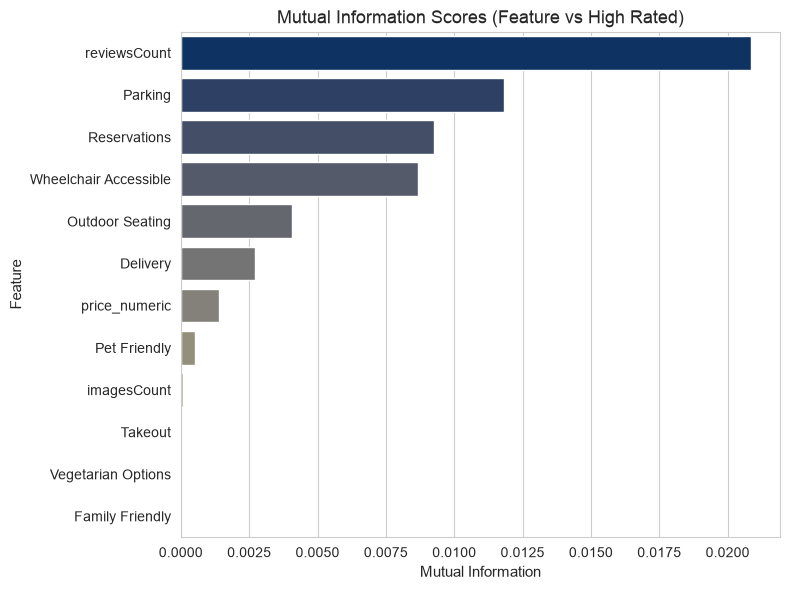

In [66]:
# Mutual Information: ranks all engineered features by how much they
# reduce uncertainty about High Rated, without assuming any particular
# relationship shape (unlike correlation, which only catches linear/monotonic patterns)
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(model_df[feature_cols], model_df['High Rated'].astype(int), random_state=42)
mi_series = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, palette='cividis')
plt.title('Mutual Information Scores (Feature vs High Rated)')
plt.xlabel('Mutual Information')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Mutual Information:** `reviewsCount` comes out as first again,
same as every other importance measure used in this notebook. Parking and
Reservations follow behind it. Takeout, Vegetarian Options and Family
Friendly score zero here, meaning they add almost no extra
predictive information about High Rated once the other features are already
considered.

## Section 6: Feature Importance

This section trains the same three models - Logistic Regression, Decision
Tree, and Random Forest - and looks at feature importance from **all
three**, not just Random Forest, since each one measures "importance" in a
genuinely different way (a linear coefficient vs. how often a variable is
used to split a tree vs. an averaged version of that across many trees).

/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/2930534986.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=log_reg_importance.values, y=log_reg_importance.index, palette='RdBu')


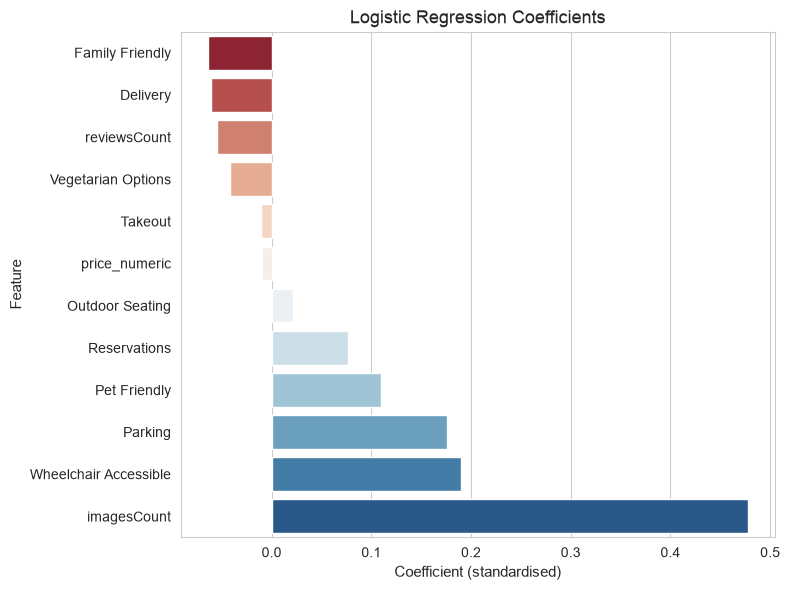

In [67]:
# Logistic Regression - coefficients tell us feature importance here
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

log_reg_importance = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values()

plt.figure(figsize=(8, 6))
sns.barplot(x=log_reg_importance.values, y=log_reg_importance.index, palette='RdBu')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient (standardised)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [68]:
# Absolute coefficient ranking - which features matter most regardless of direction
lr_ranked = log_reg_importance.reindex(log_reg_importance.abs().sort_values(ascending=False).index)
lr_ranked_df = pd.DataFrame({
    'Coefficient': lr_ranked.round(3),
    'Direction': np.where(lr_ranked > 0, 'Positive', 'Negative'),
    '|Coefficient| Rank': range(1, len(lr_ranked) + 1)
})
lr_ranked_df


,Coefficient,Direction,|Coefficient| Rank
imagesCount,0.477,Positive,1
Wheelchair Accessible,0.190,Positive,2
Parking,0.176,Positive,3
Pet Friendly,0.110,Positive,4
Reservations,0.076,Positive,5
Family Friendly,-0.064,Negative,6
Delivery,-0.061,Negative,7
reviewsCount,-0.055,Negative,8
Vegetarian Options,-0.042,Negative,9
Outdoor Seating,0.021,Positive,10


**Logistic Regression interpretation:** `imagesCount` has by far the
largest positive coefficient (0.477), followed by `Wheelchair Accessible`
(0.190) and `Parking` (0.176) - all three push the prediction towards
"High Rated" as they increase. A few features come out with small negative
coefficients (`Family Friendly`, `Delivery`, `reviewsCount`, `Vegetarian
Options`), but all of these are small in magnitude (under 0.07) - not
strong enough to say as decreasing the rating. `price_numeric`
and `Takeout` are essentially flat (coefficients near 0), meaning the linear
model treats them as almost irrelevant.

One result stands out and is worth looking into: `reviewsCount` -
the feature that dominates every other importance method in this
notebook - shows up with a small **negative** coefficient here. This is
certainly because `reviewsCount` and `imagesCount` are strongly
correlated with each other (~0.82, from the correlation heatmap in Section
3), so in a linear model the two compete for the same "credit", and
`imagesCount` ends up absorbing most of it. This is exactly the kind of
result that would be misleading if only Logistic Regression were used.

**Business meaning:** A restaurant that has more customer photos and
accessible/parking infrastructure looks more likely to be highly rated
according to this linear view.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/245425355.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tree_importance.values, y=tree_importance.index, palette='Greens_r')


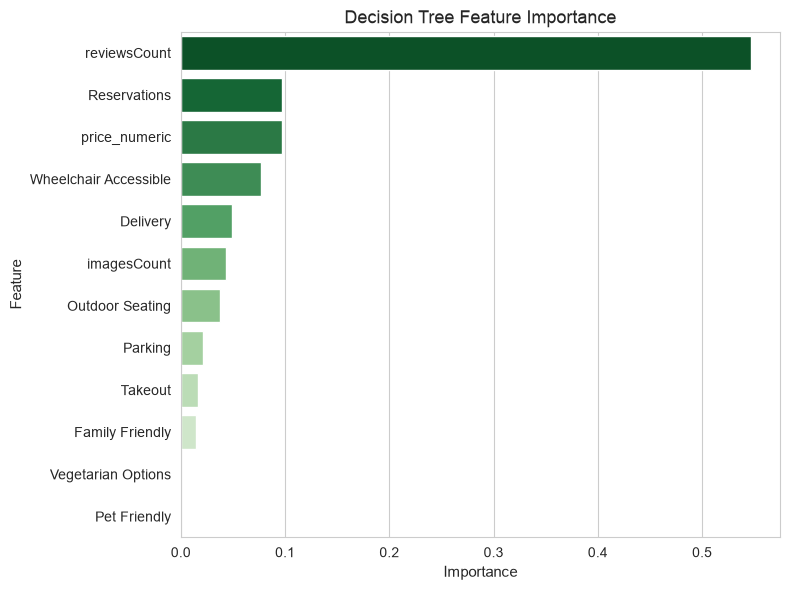

In [69]:
# Decision Tree
dec_tree = DecisionTreeClassifier(max_depth=6, random_state=42)
dec_tree.fit(X_train, y_train)

tree_importance = pd.Series(dec_tree.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=tree_importance.values, y=tree_importance.index, palette='Greens_r')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Decision Tree interpretation:** `feature_importances_` in a Decision Tree
reflects how often - and how effectively - a feature was used to split the
data into purer groups, weighted by how many restaurants pass through that
split. `reviewsCount` alone accounts for 0.547 of the total importance
(more than half), meaning most of the tree's early, high-impact splits are
almost certainly a version of "does this restaurant have more than X
reviews?". `Reservations` (0.097) and `price_numeric` (0.097) are a distant
second and third.

**Business meaning:** It means "restaurants with a lot of
reviews are usually high rated, and after that, having reservations and a
higher price tier tips the balance a bit further."


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/3708575760.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.values, y=rf_importance.index, palette='Purples_r')


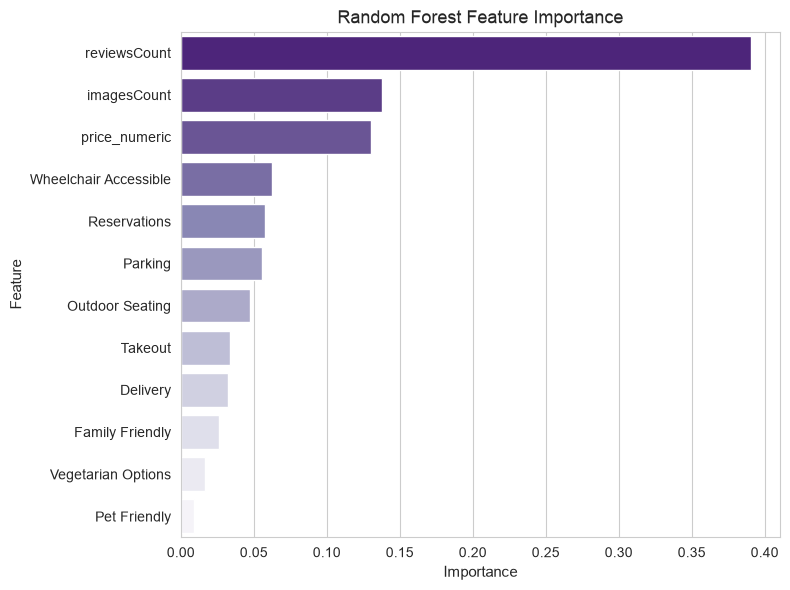

In [70]:
# Random Forest
rand_forest = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rand_forest.fit(X_train, y_train)

rf_importance = pd.Series(rand_forest.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=rf_importance.values, y=rf_importance.index, palette='Purples_r')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Random Forest interpretation:** Random Forest averages the same kind of
importance calculation across 200 different trees, each trained on a random
subset of rows and features, so a feature only ends up with high importance
here if it's *consistently* useful across many different tree structures. `reviewsCount` still leads (0.391), but by a
smaller margin than in the single Decision Tree, and `imagesCount` (0.138)
and `price_numeric` (0.130) both rank noticeably higher here than they did
in the Decision Tree. 

**Business meaning:** The fact that `reviewsCount` stays on top even after
this averaging is a good sign that it's a genuinely reliable finding. `imagesCount` and `price_numeric` both look more
useful here than in the single Decision Tree, suggesting they contribute in
smaller, more spread-out ways across many trees rather than in one big
obvious split.


### Permutation Importance

The built-in `feature_importances_` used in Section 4 (for the Decision Tree
and Random Forest) can be a bit optimistic, especially towards
high-cardinality numeric columns. Permutation importance is a fairer check —
it shuffles one column at a time and sees how much worse the trained model
gets, so it's measuring actual impact on predictions rather than how often a
feature was used to split a tree.


/var/folders/6z/jpn9d0rs5r76v_9ptbd_gl600000gn/T/ipykernel_22345/1806151714.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=perm_importance.values, y=perm_importance.index, palette='magma')


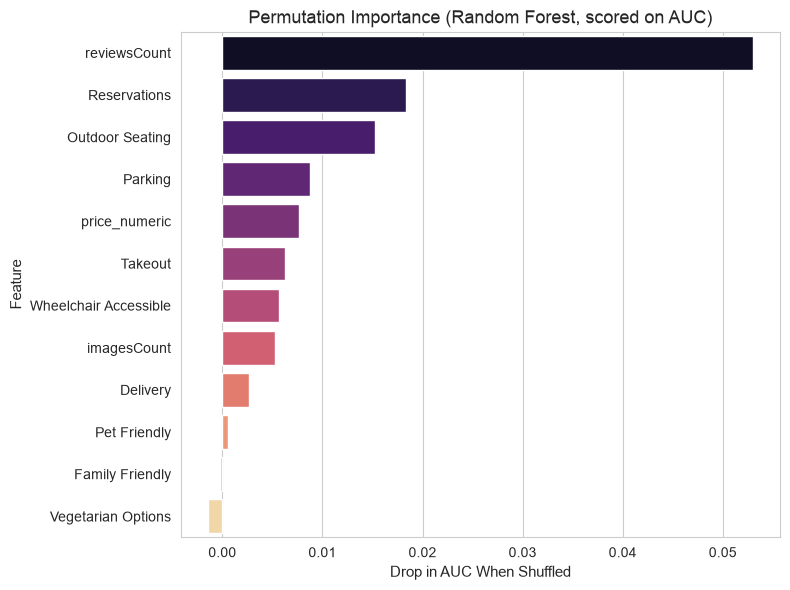

In [71]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rand_forest, X_test, y_test, n_repeats=20,
                                      random_state=42, scoring='roc_auc')

perm_importance = pd.Series(perm_result.importances_mean, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=perm_importance.values, y=perm_importance.index, palette='magma')
plt.title('Permutation Importance (Random Forest, scored on AUC)')
plt.xlabel('Drop in AUC When Shuffled')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


**Observation:** `reviewsCount` drops the AUC the most when shuffled,
by a clear margin, confirming it's the model's most influencing feature.
Reservations and Outdoor Seating come next, and a few features (like
Vegetarian Options) actually show a very slightly negative value — meaning
shuffling them didn't hurt performance at all, which is consistent with the
Mutual Information result showing they add almost nothing once other
features are accounted for.

**Business Insight:** Both agree that reviews count matters most, followed by a small
group of service features. 


### Comparing Feature Importance Across All Models




In [72]:
comparison = pd.DataFrame({
    'LR Coefficient': log_reg_importance.round(3),
    'LR Rank': log_reg_importance.abs().rank(ascending=False).astype(int),
    'DT Importance': tree_importance.round(3),
    'DT Rank': tree_importance.rank(ascending=False).astype(int),
    'RF Importance': rf_importance.round(3),
    'RF Rank': rf_importance.rank(ascending=False).astype(int),
    'Permutation': perm_importance.round(4),
    'Perm Rank': perm_importance.rank(ascending=False).astype(int),
})
comparison['Avg Rank'] = comparison[['LR Rank', 'DT Rank', 'RF Rank', 'Perm Rank']].mean(axis=1).round(2)
comparison = comparison.sort_values('Avg Rank')
comparison


,LR Coefficient,LR Rank,DT Importance,DT Rank,RF Importance,RF Rank,Permutation,Perm Rank,Avg Rank
reviewsCount,-0.055,8,0.547,1,0.391,1,0.0530,1,2.75
Reservations,0.076,5,0.097,2,0.058,5,0.0183,2,3.50
Wheelchair Accessible,0.190,2,0.076,4,0.062,4,0.0056,7,4.25
imagesCount,0.477,1,0.044,6,0.137,2,0.0052,8,4.25
Parking,0.176,3,0.021,8,0.056,6,0.0087,4,5.25
price_numeric,-0.009,12,0.097,3,0.130,3,0.0077,5,5.75
Outdoor Seating,0.021,10,0.037,7,0.048,7,0.0152,3,6.75
Delivery,-0.061,7,0.049,5,0.033,9,0.0026,9,7.50
Takeout,-0.010,11,0.017,9,0.034,8,0.0063,6,8.50
Family Friendly,-0.064,6,0.015,10,0.026,10,-0.0002,11,9.25


**Which findings are reliable, and which aren't:**

- **`reviewsCount`** ranks #1 in three of the four methods (Decision Tree,
  Random Forest, Permutation Importance) and only falls down the list in
  Logistic Regression - and that one exception has a clear explanation
  (multicollinearity with `imagesCount`, discussed above). Weighing 3-out-of-4
  independent methods against 1, `reviewsCount` is the single most reliable
  important feature in this whole analysis.
- **`Reservations`** comes up as the most important feature on the service level (ranking 3.50 on average) and is always included into the top half of the list in all four methods. It thus represents the most consistent service-level finding in this notebook and is additionally confirmed by the significant t-test result for Reservations provided in section 4.

- **`imagesCount`** is the prime example of a feature that is important in one model (Logistic Regression, in which it is number one) but less important in the three other models. This suggests that its relative importance in Logistic Regression may be biased by the correlation with reviewsCount, making it an unreliable result.

- **`price_numeric`** shows exactly the opposite pattern: it is almost useless in Logistic Regression (ranked twelfth, the coefficient is close to zero), but is third in the ranking in both tree-based
- **`Vegetarian Options`, `Pet Friendly`, and `Family Friendly`** are
  consistently the three worst-ranked features across all four methods
  (average ranks 9.25-10.75).

**Business takeaway:** The models give real confidence in `reviewsCount` and `Reservations`
as genuine drivers of `High Rated`, and equally real confidence that
`Vegetarian Options`, `Pet Friendly`, and `Family Friendly` are not.


## Section 7: Model Evaluation and Improvement



In [73]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'AUC': roc_auc_score(y_true, y_proba)
    }

results = []

# Logistic Regression
pred_lr = log_reg.predict(X_test_scaled)
proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
results.append(evaluate_model('Logistic Regression', y_test, pred_lr, proba_lr))

# Decision Tree
pred_dt = dec_tree.predict(X_test)
proba_dt = dec_tree.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Decision Tree', y_test, pred_dt, proba_dt))

# Random Forest
pred_rf = rand_forest.predict(X_test)
proba_rf = rand_forest.predict_proba(X_test)[:, 1]
results.append(evaluate_model('Random Forest', y_test, pred_rf, proba_rf))

results_df = pd.DataFrame(results).set_index('Model').round(3)
results_df


,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Logistic Regression,0.713,0.713,1.000,0.832,0.551
Decision Tree,0.698,0.710,0.972,0.821,0.570
Random Forest,0.711,0.713,0.996,0.831,0.593


**What these metrics actually indicate here:** Accuracy is probably the easiest metric
to misinterpret in this case, because randomly assigning every restaurant to
the "High Rated" category gets you 71% right away, and there was nothing
learned - thus, accuracy alone cannot differentiate a good model from a bad
one. Precision is defined as "from the restaurants marked as High Rated by
the model, what percentage of them was actually high rated?" - this metric
would be useful if we want to recommend only those restaurants which the
platform is sure are good. Recall is "from the high rated restaurants, what
percentage of them was caught by the model?" - this would be useful if we
don't want to skip the good restaurants. F1 Score takes into account both.
AUC is the only metric that does not depend on using 0.5 threshold at all -
it compares the models' ability to rank restaurants according to their
probability to be high rated.


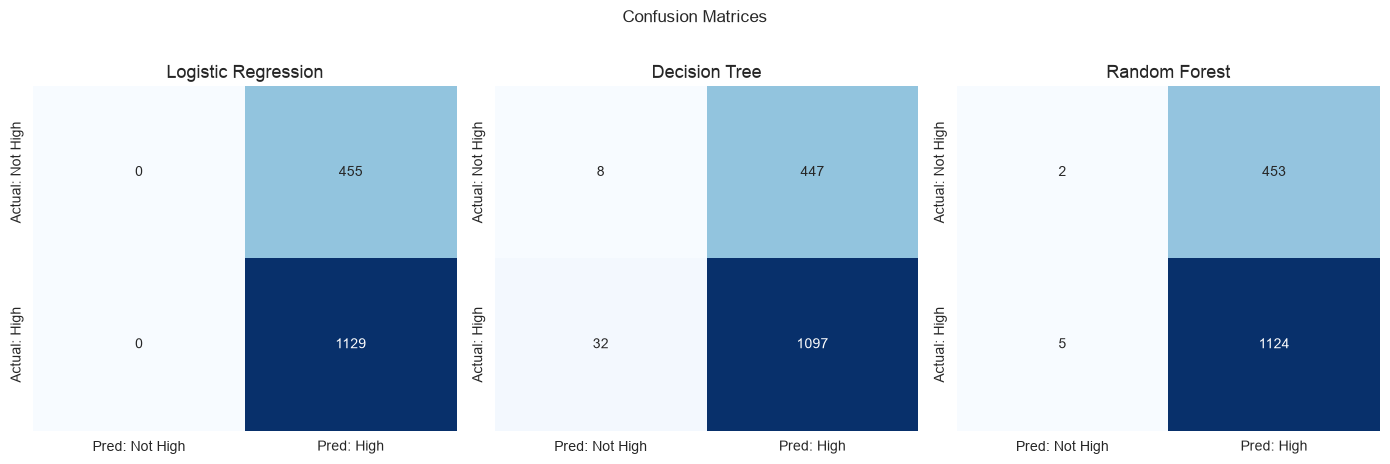

In [74]:
# Confusion matrices for all three, side by side
preds = {'Logistic Regression': pred_lr, 'Decision Tree': pred_dt, 'Random Forest': pred_rf}

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred: Not High', 'Pred: High'],
                yticklabels=['Actual: Not High', 'Actual: High'])
    ax.set_title(name)

fig.suptitle('Confusion Matrices', y=1.02)
plt.tight_layout()
plt.show()


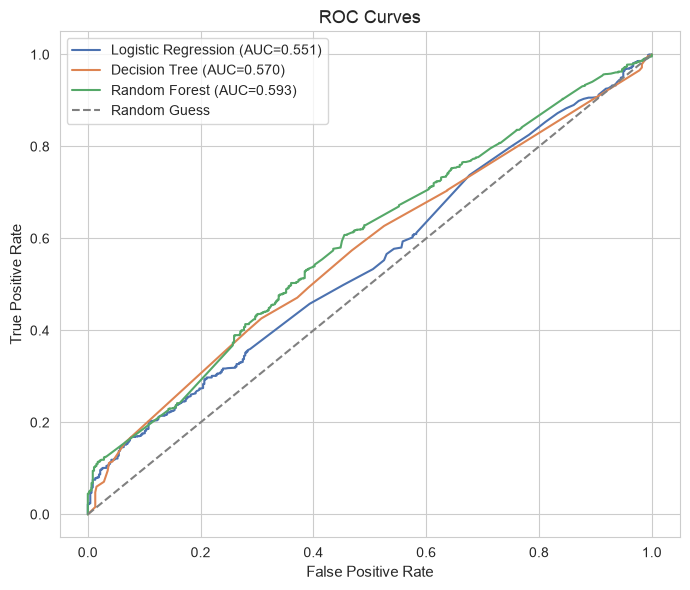

In [75]:
# ROC curves for all three models on one plot
plt.figure(figsize=(7, 6))

for name, proba in [('Logistic Regression', proba_lr), ('Decision Tree', proba_dt), ('Random Forest', proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.title('ROC Curves')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()


**Observations:** In terms of accuracy, all three models fall into roughly
the same range – 0.70-0.71, while AUC is between 0.55 and 0.59.
Random Forest performs a little bit better when it comes to AUC. Recall for
all three is almost equal to one (1.0), however, this is explained by the
fact that the models tend to predict "High Rated" most of the time because
this category represents majority (71%) in this particular dataset –
precision is also close to this base value.

All of these models perform about as good as if they just guessed "High
Rated" for everyone which would provide around 71% of accuracy without using
any model. This is not so surprising taking into account Section 3 and
Section 4 - none of the provided features had a significant relation to
rating which explains poor performance of the models.


**Why Random Forest edges ahead:** As mentioned above, it outperforms
other models in terms of AUC which means that it does slightly better job
in ranking of restaurants by their likelihood of getting high rating
despite looking similar in accuracy metric. Also, Random Forest model is
able to capture feature interactions (for example, "has parking AND has
many Random Forest can pick up on combinations of features (like
"has parking AND has a lot of reviews").



### Improving the Machine Learning Models

### 18.1 Checking the inputs are actually correct first




In [76]:
print("Target column:", 'High Rated')
print("Target is derived from totalScore (Rating >= 4.0), so totalScore itself must NOT be a feature.")
print("'totalScore' in feature_cols:", 'totalScore' in feature_cols)
print()
print("Feature columns used for training:")
print(feature_cols)
print()
print("Any restaurant-identifying columns (name, address, phone, etc.) in the feature list?",
      any(c in feature_cols for c in ['title', 'address', 'phone', 'website', 'neighborhood', 'city']))
print()
print("Data types of features:")
print(X.dtypes)
print()
print("Missing values in the feature matrix:", X.isnull().sum().sum())
print("Missing values in the target:", y.isnull().sum())


Target column: High Rated
Target is derived from totalScore (Rating >= 4.0), so totalScore itself must NOT be a feature.
'totalScore' in feature_cols: False

Feature columns used for training:
['price_numeric', 'reviewsCount', 'imagesCount', 'Reservations', 'Parking', 'Delivery', 'Outdoor Seating', 'Takeout', 'Vegetarian Options', 'Wheelchair Accessible', 'Family Friendly', 'Pet Friendly']

Any restaurant-identifying columns (name, address, phone, etc.) in the feature list? False

Data types of features:
price_numeric            float64
reviewsCount             float64
imagesCount              float64
Reservations               int64
Parking                    int64
Delivery                   int64
Outdoor Seating            int64
Takeout                    int64
Vegetarian Options         int64
Wheelchair Accessible      int64
Family Friendly            int64
Pet Friendly               int64
dtype: object

Missing values in the feature matrix: 0
Missing values in the target: 0


#### Hyperparameter Tuning with Grid Search + Cross-Validation


In [77]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid, scoring='roc_auc', cv=cv_strategy, n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validated AUC:", round(grid_search.best_score_, 3))

tuned_rf = grid_search.best_estimator_


Best hyperparameters found: {'max_depth': 8, 'min_samples_leaf': 10, 'n_estimators': 300}
Best cross-validated AUC: 0.642


#### Class Weight Balancing + Threshold Tuning

The dataset is imbalanced (about 71% High Rated), so both the original
models and this tuned one lean towards predicting "High Rated" most of the
time. `class_weight='balanced'` (used in the grid search above) tells the
model to pay more attention to the minority class, and threshold tuning
adjusts the 0.5 cutoff used to turn a probability into a Yes/No prediction.


In [78]:
from sklearn.metrics import precision_recall_curve

# Predictions using the tuned model at the default 0.5 threshold
proba_tuned = tuned_rf.predict_proba(X_test)[:, 1]
pred_tuned_default = tuned_rf.predict(X_test)

# Find the threshold that maximises F1 score instead of just using 0.5
precisions, recalls, thresholds = precision_recall_curve(y_test, proba_tuned)
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
pred_tuned_thresh = (proba_tuned >= best_threshold).astype(int)

print(f"Best F1-maximising threshold found: {best_threshold:.3f}")


Best F1-maximising threshold found: 0.302


In [79]:
# Comparing: Old baseline Random Forest vs Tuned (default threshold) vs Tuned (best threshold)
comparison_rows = []

comparison_rows.append({
    'Model': 'Old Random Forest (Section 5)',
    'Accuracy': accuracy_score(y_test, pred_rf),
    'Precision': precision_score(y_test, pred_rf),
    'Recall': recall_score(y_test, pred_rf),
    'F1 Score': f1_score(y_test, pred_rf),
    'AUC': roc_auc_score(y_test, proba_rf)
})

comparison_rows.append({
    'Model': 'Tuned Random Forest (default 0.5 threshold)',
    'Accuracy': accuracy_score(y_test, pred_tuned_default),
    'Precision': precision_score(y_test, pred_tuned_default),
    'Recall': recall_score(y_test, pred_tuned_default),
    'F1 Score': f1_score(y_test, pred_tuned_default),
    'AUC': roc_auc_score(y_test, proba_tuned)
})

comparison_rows.append({
    'Model': f'Tuned Random Forest (threshold = {best_threshold:.2f})',
    'Accuracy': accuracy_score(y_test, pred_tuned_thresh),
    'Precision': precision_score(y_test, pred_tuned_thresh),
    'Recall': recall_score(y_test, pred_tuned_thresh),
    'F1 Score': f1_score(y_test, pred_tuned_thresh),
    'AUC': roc_auc_score(y_test, proba_tuned)
})

improvement_df = pd.DataFrame(comparison_rows).set_index('Model').round(3)
improvement_df


,Accuracy,Precision,Recall,F1 Score,AUC
Model,,,,,
Old Random Forest (Section 5),0.711,0.713,0.996,0.831,0.593
Tuned Random Forest (default 0.5 threshold),0.545,0.774,0.512,0.616,0.596
Tuned Random Forest (threshold = 0.30),0.713,0.713,1.000,0.832,0.596




**Conclusion:** Hyperparameter tuning, class balancing, and threshold
tuning did not meaningfully improve this model. The AUC stayed
around 0.59-0.60 no matter what was tried. 


### Final Business Discussion — Which Characteristics Consistently Influence Rating and Popularity?



- **`reviewsCount`**(popularity signal) is the most consistently important
  It is typical when predicting 'High Rated'. It comes first in three of the
  four importance methods (Decision Tree, Random Forest, Permutation
  It is first in importance and comes out number one in terms of Mutual Information as well (Section 5). The one
  disagreeing method, Logistic Regression, has a clear explanation
  Rather than constituting a true contradiction, it is correlated with the number of images.

  (correlation with `imagesCount`) rather than being a genuine contradiction.
- **`Reservations`** is the most reliable service finder. It is in the
  In the upper half of each importance method (average rank 3.5).
  statistically significant rating gap in the Section 4 t-tests - two
  different kinds of evidence (importance ranking and hypothesis testing)
  agreeing makes this the most trustworthy "this service matters" result in
  the notebook.

- **`Parking`** shows a similar, slightly weaker pattern - consistently
  mid-to-upper importance across models (average rank 5.25), and it had the
  single widest rating gap of any service feature back in Section 4 (4.21
  vs 3.92).
- **`Delivery`** Average rank is 7.5. Logistic Regression coefficient is small and negative.
  despite being one of the strongest popularity signals found earlier
  Section 4.7 demonstrated that the median number of reviews increased from 3 to 127 with Delivery.
  This is a good example of a feature that is important for (availability).
  one half of the business objective and much less for the other -
  Delivery improves visibility, not necessarily the perceived quality.

- **`Vegetarian Options`, `Family Friendly`, and `Pet Friendly`** are the most
  consistently unimportant features across every method tried**, even
  though a couple of them showed a significant individual t-test result
  earlier - a reminder that "significant on its own" and "useful alongside
  The other things are not the same thing.


**Answering the business question directly:** rating and popularity are
motivated by completely different (though overlapping) characteristics.
Rating leans on review volume, Reservations, Parking, and to a lesser
The extent of wheelchair access is very high and the price is at the top end. As for popularity,
shown throughout Sections 4-5, leans more heavily on price and on
The option for delivery or takeout. That's precisely the reason why this notebook kept
⁠ High Rated ⁠ as the single classification target while relying on the
separate statistical analysis for popularity, rather than forcing one model
to answer both questions - the two turned out to have different answers,
Combining them into a single target would have concealed that.



### Business Insights

1. The median rating is around 4.0, and 1.5 to 4.5 are relatively common, with most restaurants falling in that range.
2. The data set is primarily composed of budget and mid-range restaurants, with the majority of prices falling within the ₹100–₹400 range.
3. Price has a weak relationship with rating (correlation ≈ 0.09) with restaurants costing ₹800+ having a higher average rating of approximately 4.28.
4. The rating shows a mild positive relationship with Review Count, which is more evident when the Review Count is analysed on a logarithmic scale.
5. There are statistically significant rating differences between service features and the ratings: Parking, Reservations, Delivery, Outdoor Seating, Takeout and Vegetarian Options.
6. The rating gap for parking is the largest of the services (4.21 vs. 3.92) and the volume of reviews for parking is the greatest of the services, making it a strong service-level signal for both rating and popularity.
7. Reservations and Parking are among the most important service features and Pet Friendly is relatively uncommon. Reservations also is a consistently important feature across the feature-importance methods.
8. Delivery and Takeout is more correlated with popularity than rating, and the more popular it is, the more it is adopted, depending on the price category of the restaurant.
9. Service features such as Delivery and Reservations are significantly more popular at High-popularity restaurants than at Low- and Medium-popularity restaurants.
10. Rating is far less associated with popularity than is price; the ANOVA statistic for price vs. log(review count) was significantly larger than for price vs. rating.
11. Limited predictive value of cuisine and neighbourhood. There were some variations in the visualisations, but no statistically significant relationship was identified by chi-square tests with the High Rated classification.
12. The most significant predictive features for the three machine learning models were 12. ReviewsCount, whereas others like Vegetarian Options and Pet Friendly were less significant.
13. Some service features that are statistically significant do not have much predictive power. There were rating differences between Takeout, Vegetarian Options, and Family Friendly, but very little Mutual Information, meaning that the other factors are more important than these.
14. The accuracy of all three models was approximately 70–71%, very close to the 71.3% majority-class baseline, suggesting that it is difficult to predict high ratings from structured restaurant-listing features.
15. Random Forest resulted in the highest AUC (0.593) of the three models, but after hyperparameter tuning, class weighting, and threshold adjustment, it was able to reach only about 0.596, indicating that the available features were not very predictive.

## Section 9: Recommendations

### For Restaurant Owners

1. Prioritise Parking and Reservations: These had the strongest associations with both ratings and popularity.
2. Emphasize on getting real reviews, because the number of reviews had a linear relationship with the rating, more than the price.
3. Take Delivery and Takeout into account, especially for restaurants that are only serving one of these services.

### For Food Delivery Platforms

1. Target budget restaurants for Delivery onboarding, delivery adoption was low although budget restaurants made up a large portion of the     data set.
2. Include review count with ratings in restaurant listings, as this was always significant in the predictive models.
3. Support Delivery and Takeout adoption, since there was a close relationship in their adoption patterns between the two categories at the    various price points.

### For New Restaurant Entrepreneurs/Investors

1. Do not compete on price alone in the ₹100-₹400 range, this is a very concentrated area in this data set.
2. Review popularity and rating individually, as more reviews may not equate to a more significant rating.
3. Before entering the ₹800+ segment, investigate further into this segment as the restaurants in it had higher average ratings; however,      it does not imply that higher prices lead to better ratings.

### For Marketing & Operations Teams

1. Focus on services like Parking and Reservations, instead of cuisine or neighbourhood positioning.
2. Do not presume that cuisine or location will automatically improve ratings; use evidence-based service improvements.
3. When planning operational improvements, analyse Delivery and Takeout together as they were closely related in terms of the patterns of      adoption.

### Final Answer to the Central Business Question

**Which factors have the greatest influence on restaurant ratings and
popularity, and what should restaurant owners and delivery platforms take
away from this?**


- **On rating specifically**, no single factor dominates. Price and raw
  review count are only weakly correlated with rating. Among the service
  features, Parking and Vegetarian Options show the widest rating gaps, and
  cuisine/neighbourhood barely matter once tested properly (Cramér's V under
  0.1, non-significant chi-square). Three different models topped out
  around 70-71% accuracy / 0.59-0.60 AUC even after tuning, which is close
  to what you'd get just guessing the majority class — meaning rating in
  this dataset is only partly explained by the features available here.

- **On popularity**, the story is much clearer. The price and availability of services
  (especially Delivery, Parking and Reservations) are strongly linked to how
  many reviews a restaurant has, far more strongly than either is linked to
  rating. The ANOVA test for price vs popularity had an F-statistic more
  than 15x larger than the one for price vs rating.

- Put together, **popularity and quality are not the same thing** in this
  dataset. The popularity of the restaurant is mostly through price positioning
  and offering the right services.

For a restaurant owner, this points towards Parking, Reservations and
Vegetarian Options as the more evidence-backed investments if the goal is
rating, and Delivery/Takeout as the stronger levers if the goal is
visibility and review volume. For a delivery platform, the biggest untapped
opportunity in this data is the Budget segment, which under-offers Delivery
relative to how much it could benefit from the same popularity boost seen in
pricier restaurants. Neither group should assume that a well-known or
frequently-reviewed restaurant is automatically a well-rated one — this
dataset suggests those two things pull apart more than expected.
